#### Scaling parameters of SEIR model
Here we check the approach of scaling population size proportional to underreporting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
import random
from collections import Counter, defaultdict
from scipy import integrate
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import tqdm
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score
import scipy
from sklearn.linear_model import LinearRegression
import time
import sys
import os
import matplotlib as mpl

sys.path.append(os.path.dirname(os.getcwd())) # define path to the project for convenoent relative import

from simulation.SEIR_model import SEIRModel
from simulation.model_output import SEIRModelOutput
from simulation.error_model import NaiveErrorModel

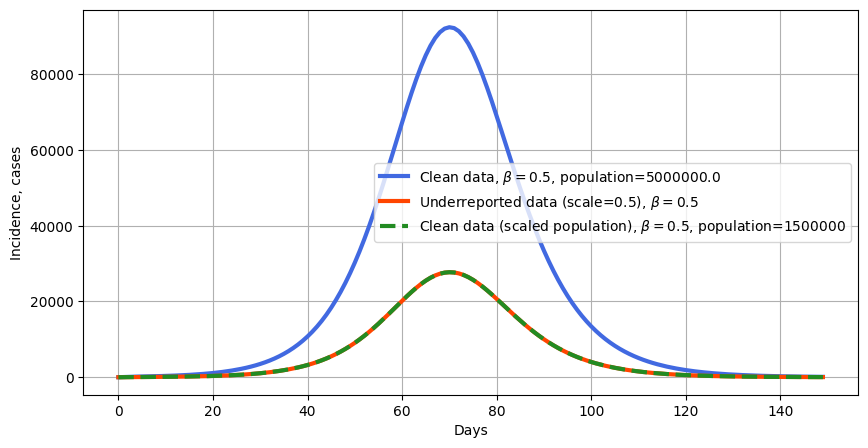

In [2]:
population = 5*1e6
model = SEIRModel(population=population)
R_0 = 2

t_incubation = 2 # in days
t_infective = 4 # in days

gamma = 1/t_incubation
delta = 1/t_infective
beta = delta*R_0
init_inf_frac = 0.0001
init_rec_frac = 0.1
tmax = 150 # days

mean_underreporting = 0.3
data_full = model.simulate(beta=beta, gamma=gamma, delta=delta, init_inf_frac=init_inf_frac, init_rec_frac=init_rec_frac)
error_model = NaiveErrorModel(data_full.daily_incidence, mean_delay=0, mean_underreporting=mean_underreporting, error_mode='fixed')
error_model.add_noise()
data_underreported = error_model.incidence_arr

model = SEIRModel(population=population*mean_underreporting)
data_pop_scaled = model.simulate(beta=beta, gamma=gamma, delta=delta, init_inf_frac=init_inf_frac, init_rec_frac=init_rec_frac)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_full.daily_incidence, color='RoyalBlue', lw=3, alpha=1, label=r'Clean data, $\beta={}$, population={}'.format(round(beta, 2), population))
ax.plot(data_underreported, color='OrangeRed', alpha=1, lw=3, label=r'Underreported data (scale=0.5), $\beta={}$'.format(round(beta, 2)))
ax.plot(data_pop_scaled.daily_incidence, '--', color='ForestGreen', lw=3, alpha=1, label=r'Clean data (scaled population), $\beta={}$, population={}'.format(round(beta, 2), round(population*mean_underreporting)))

ax.set_xlabel('Days')
ax.set_ylabel('Incidence, cases')
ax.legend()
ax.grid()
fig.savefig('../figures/scale_population.png', bbox_inches='tight')

In [ ]:
list(reversed(mean_underreporting_arr))

  9%|▉         | 1/11 [02:46<27:45, 166.58s/it]C:\Users\user\AppData\Local\Temp\ipykernel_4744\3892823436.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6,6))
100%|██████████| 11/11 [29:17<00:00, 159.77s/it]


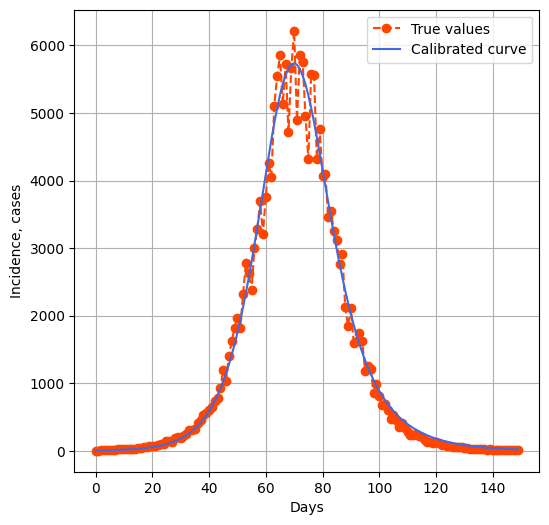

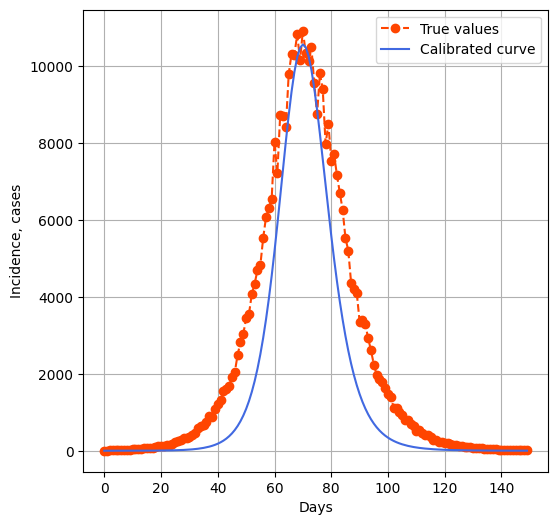

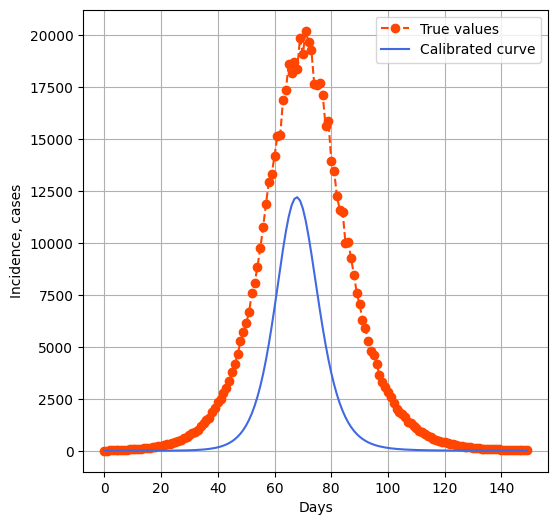

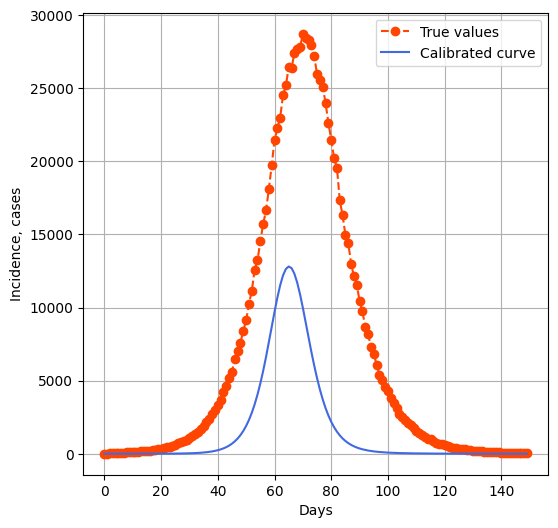

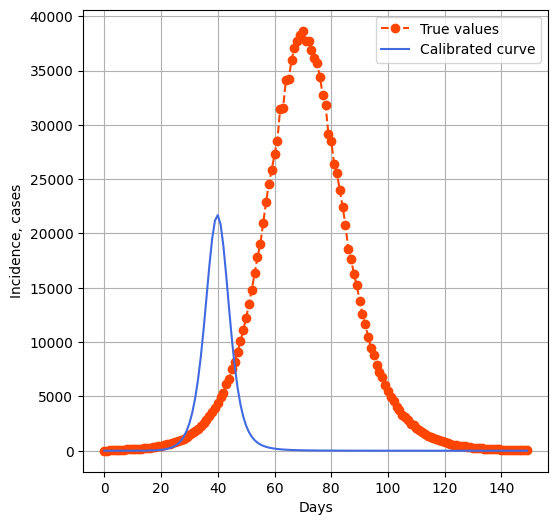

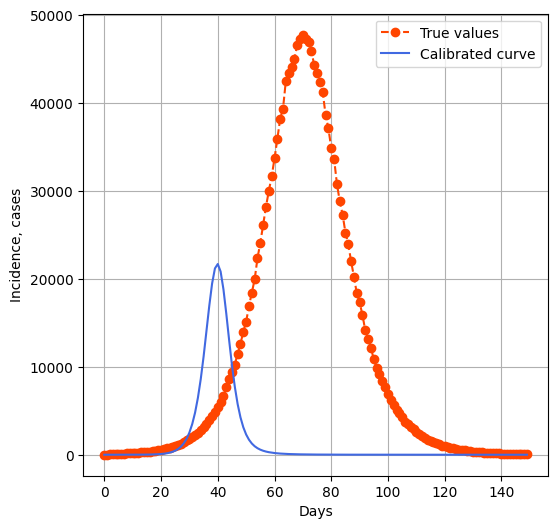

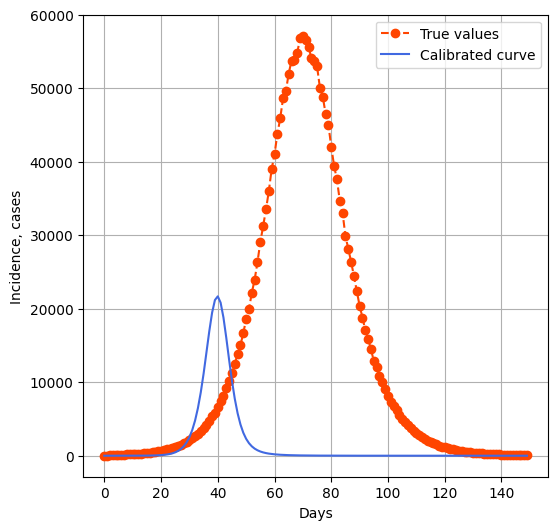

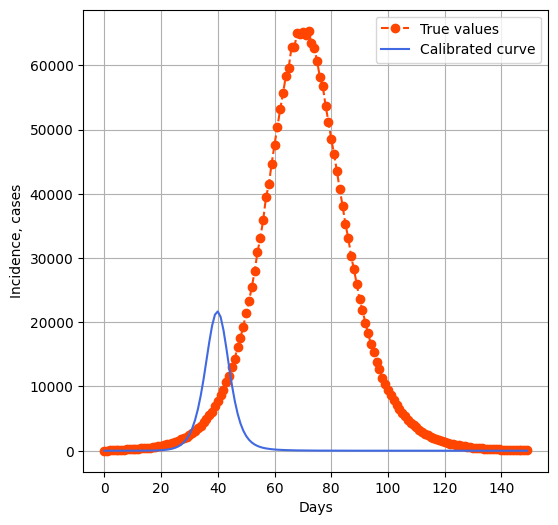

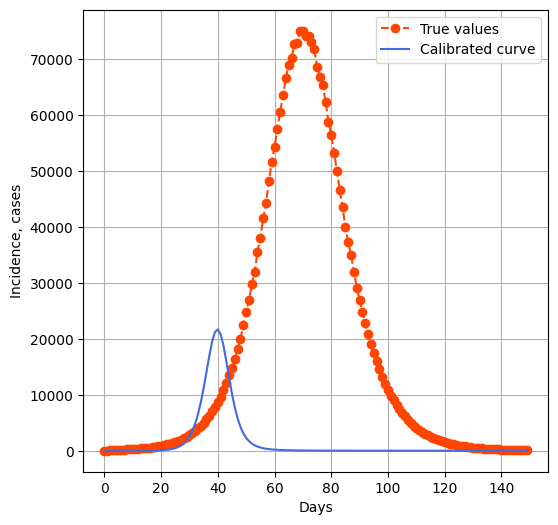

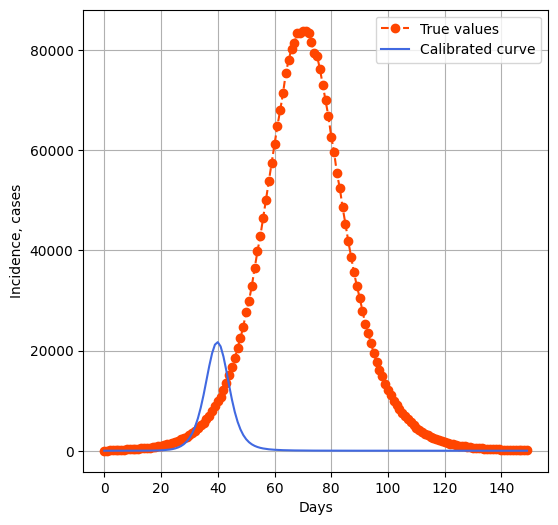

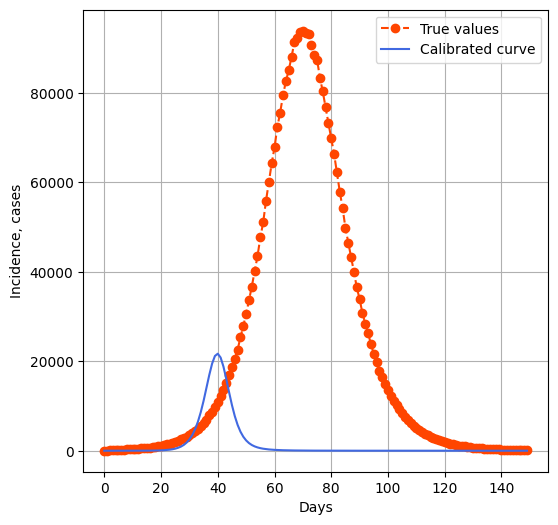

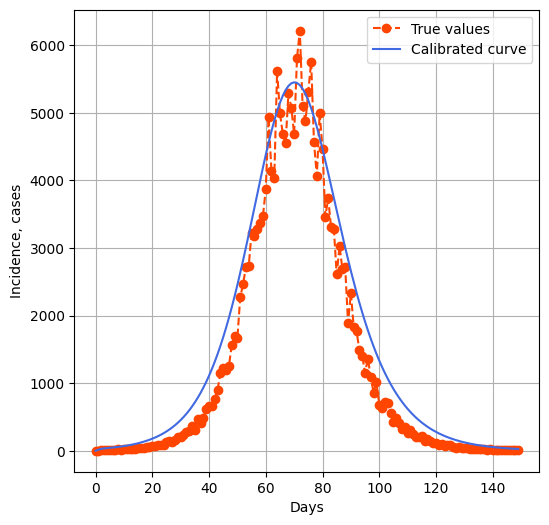

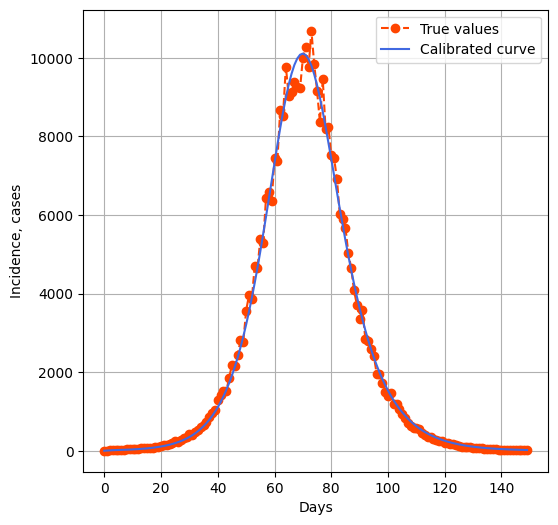

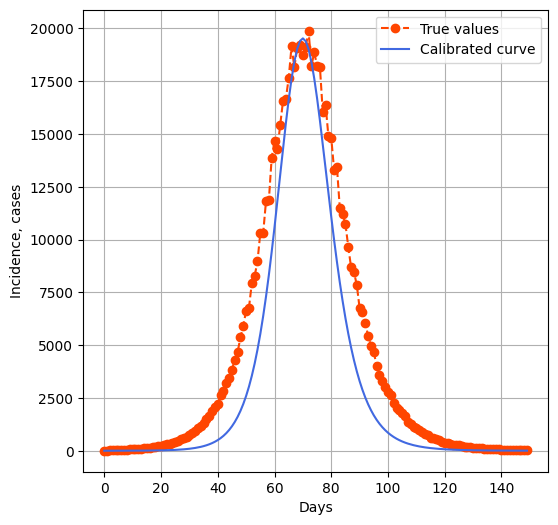

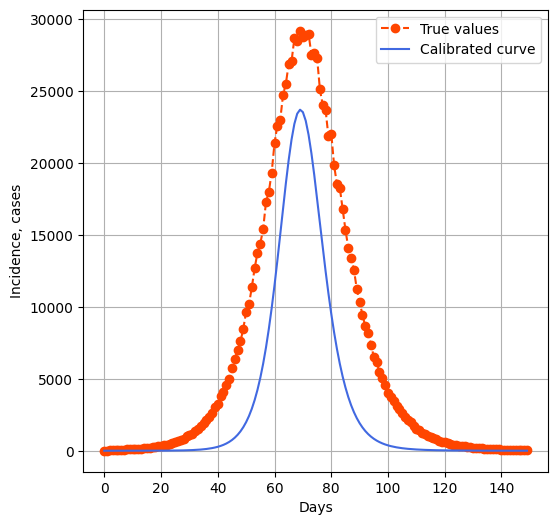

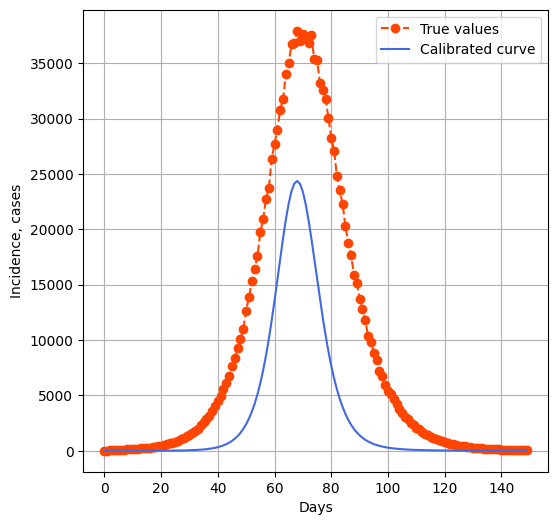

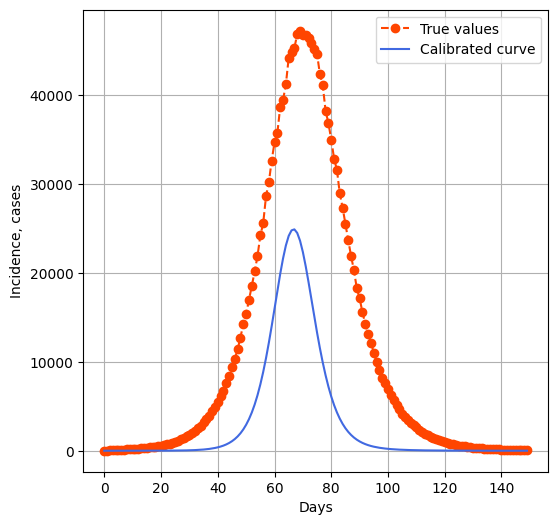

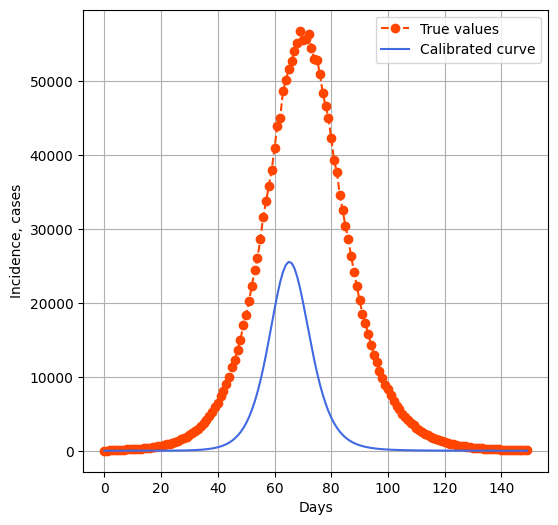

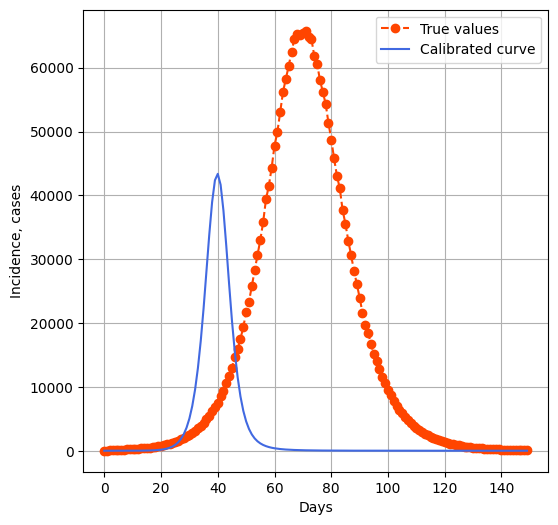

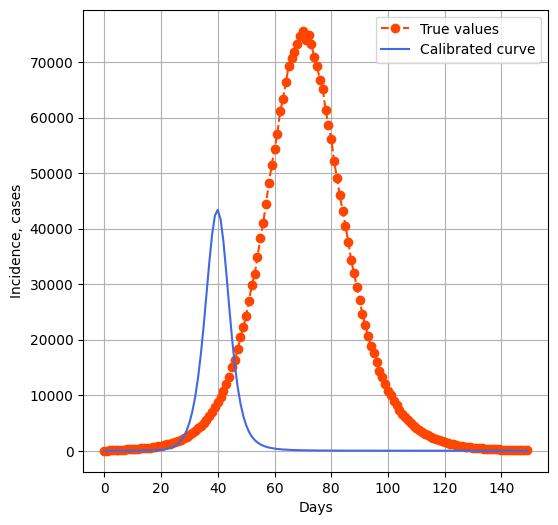

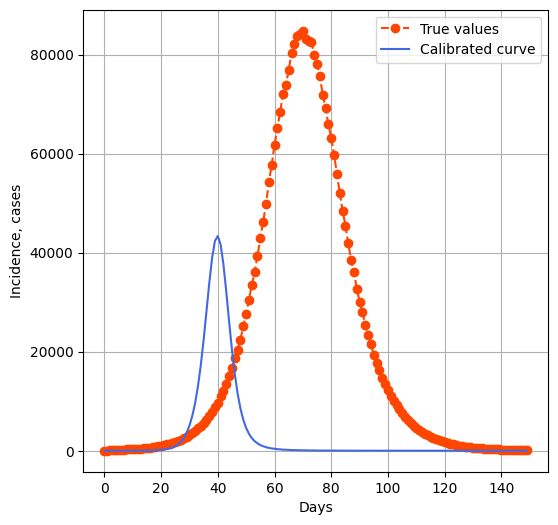

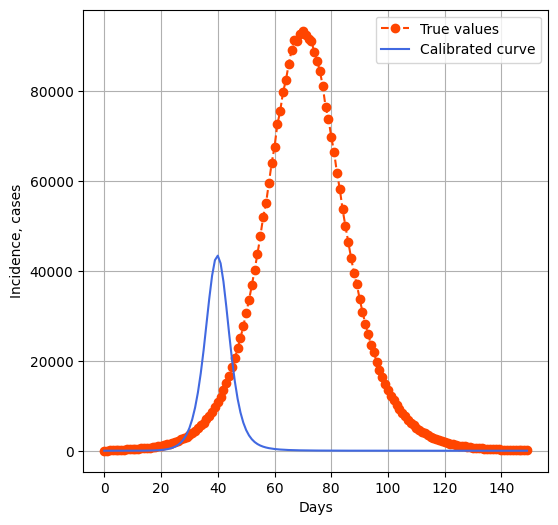

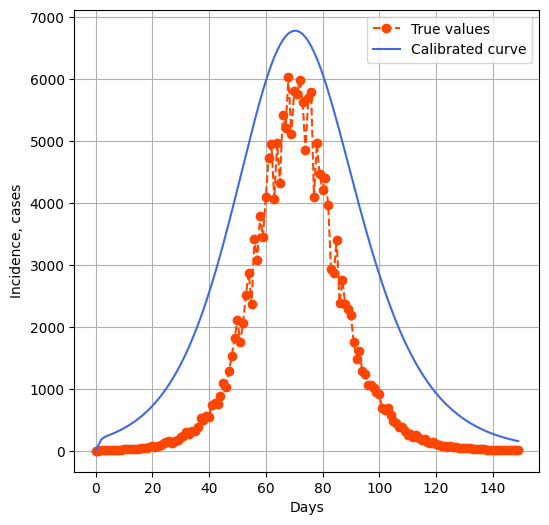

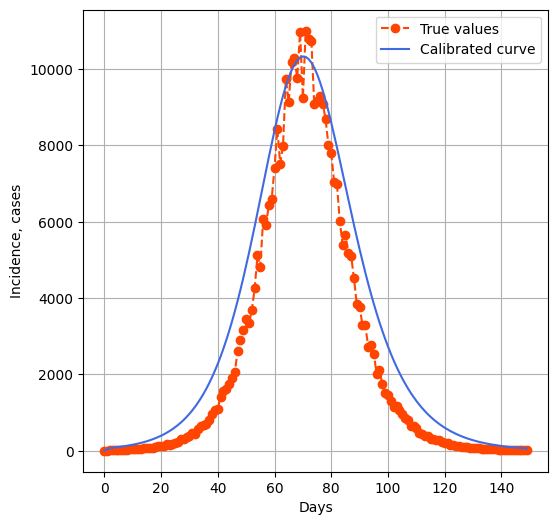

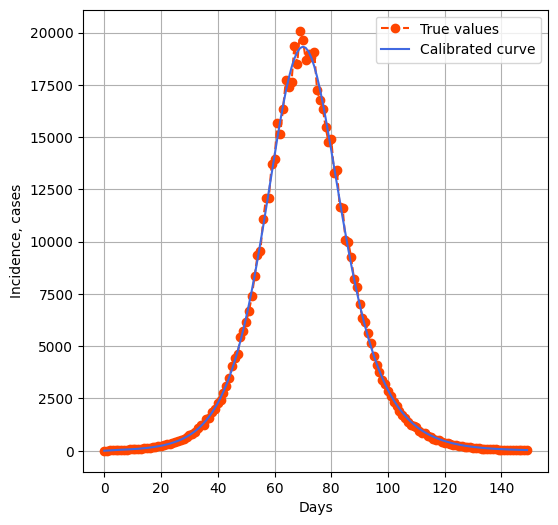

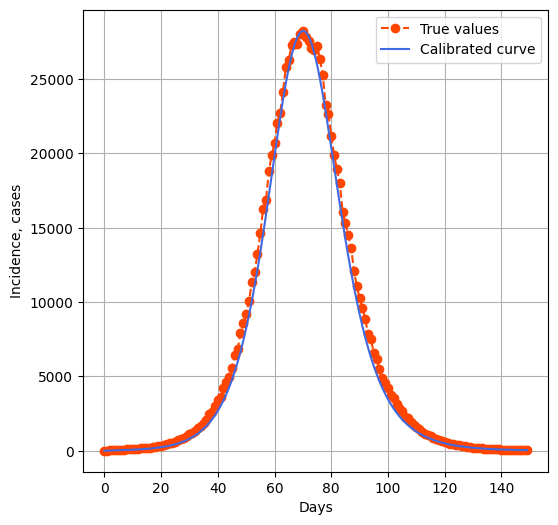

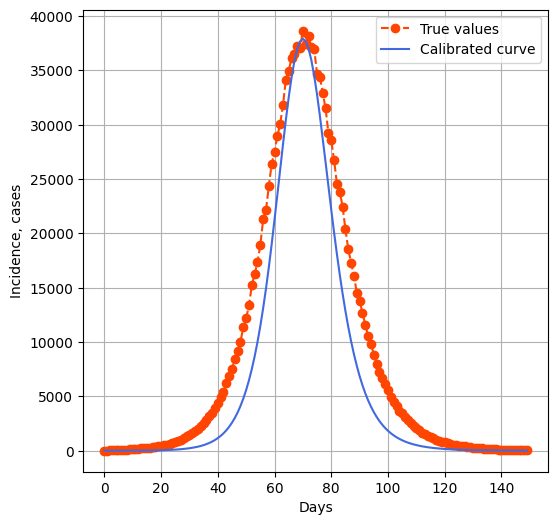

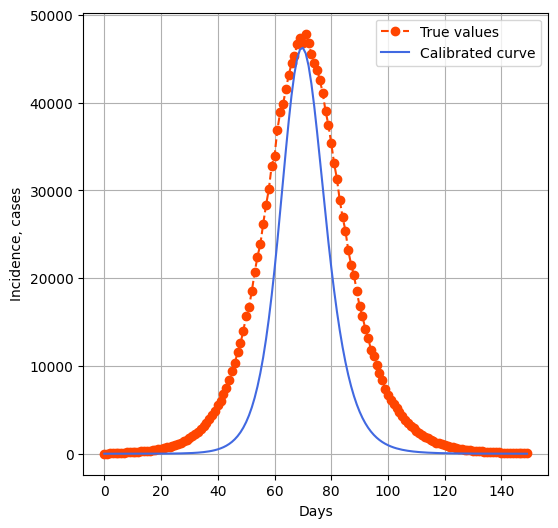

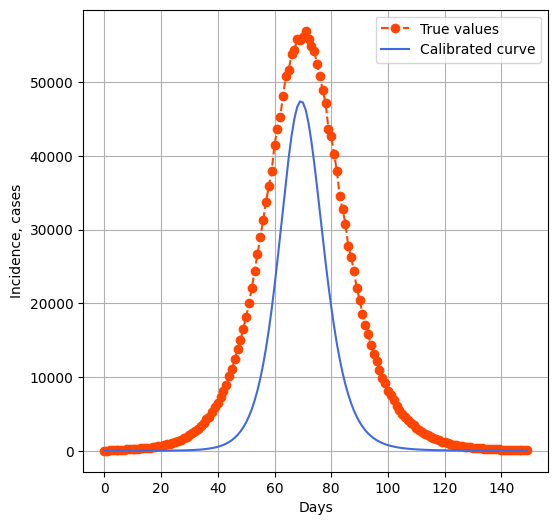

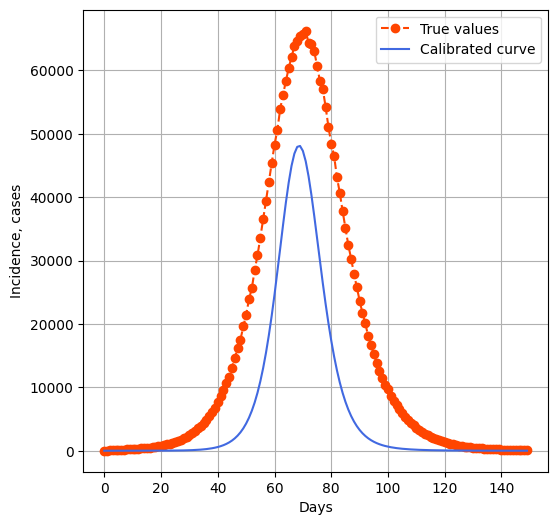

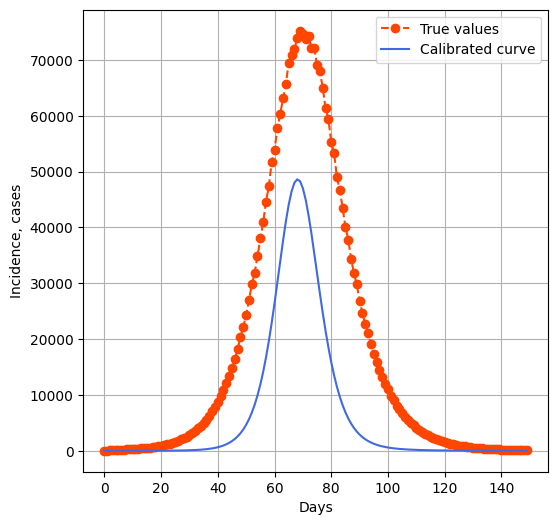

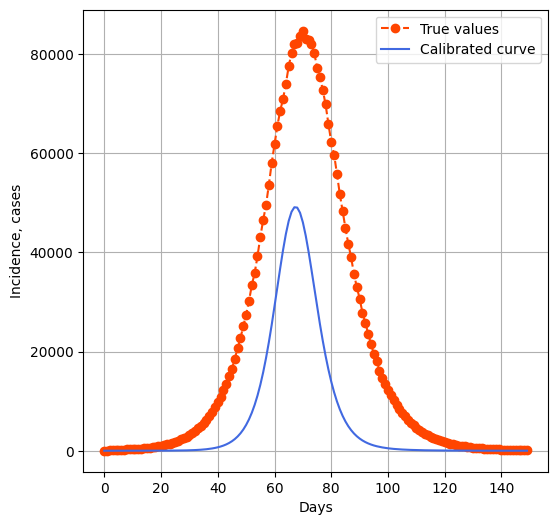

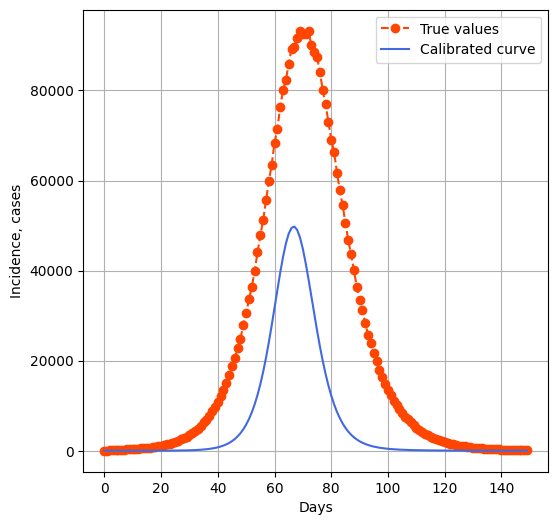

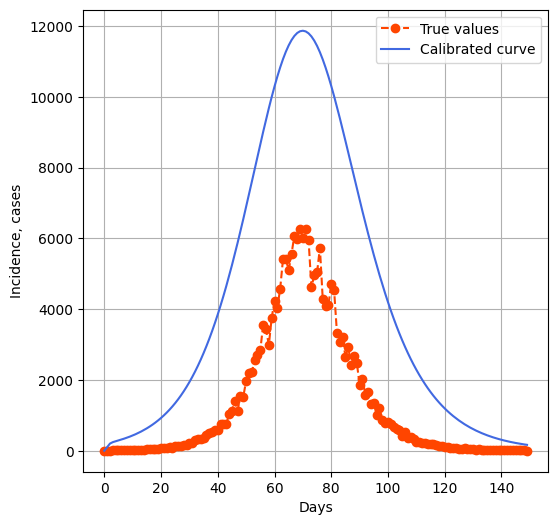

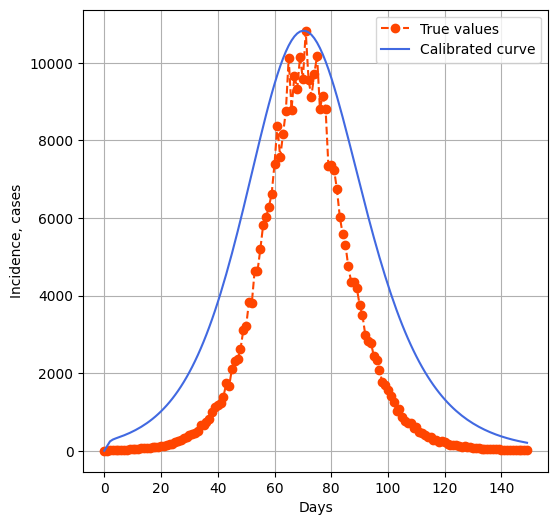

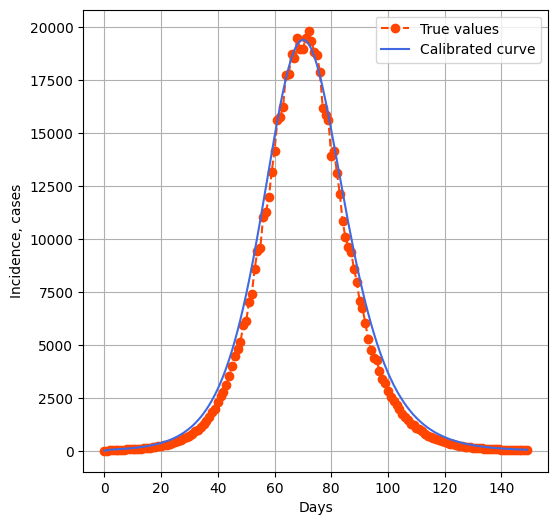

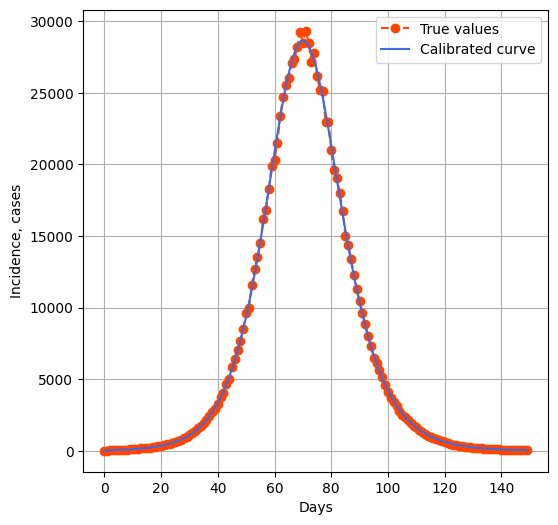

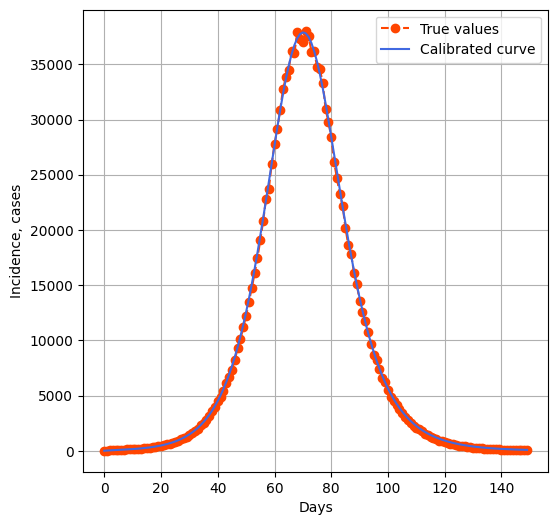

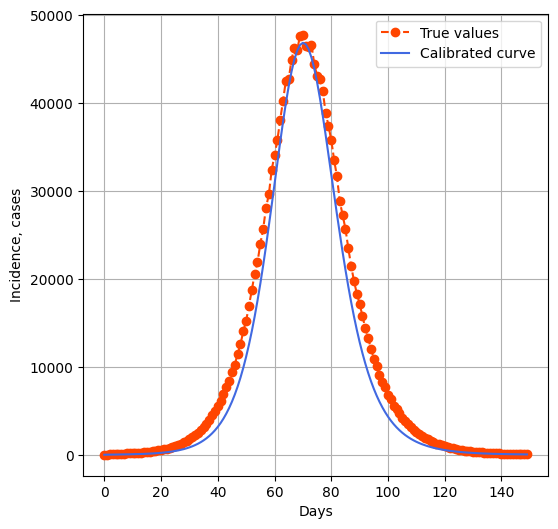

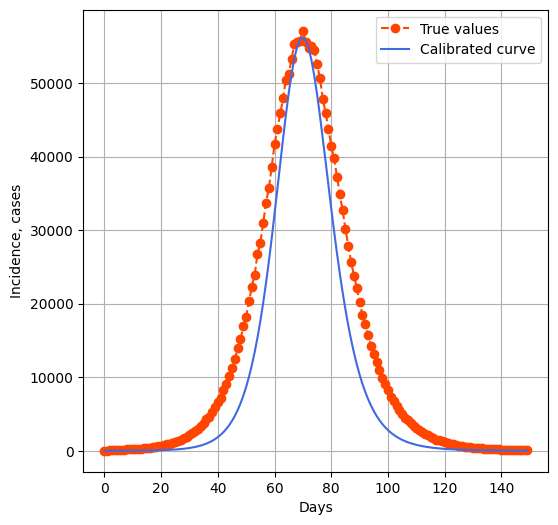

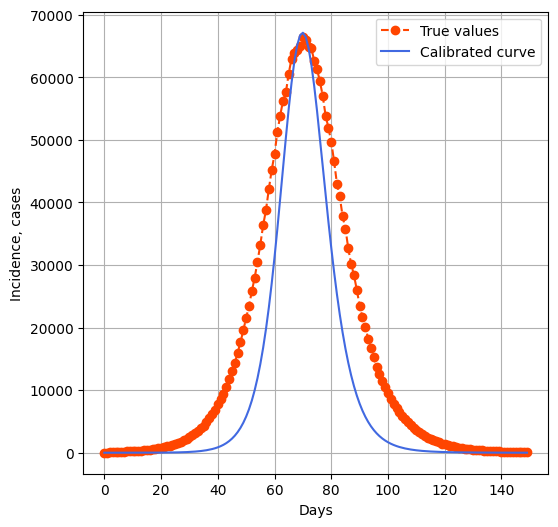

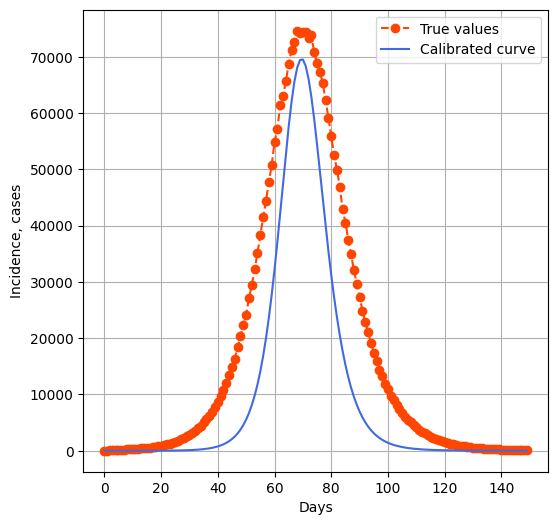

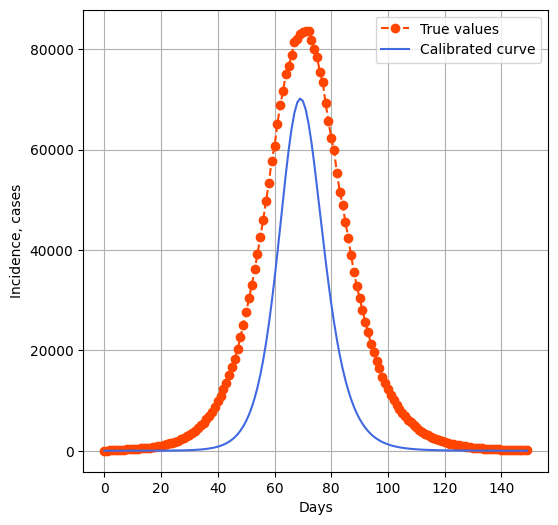

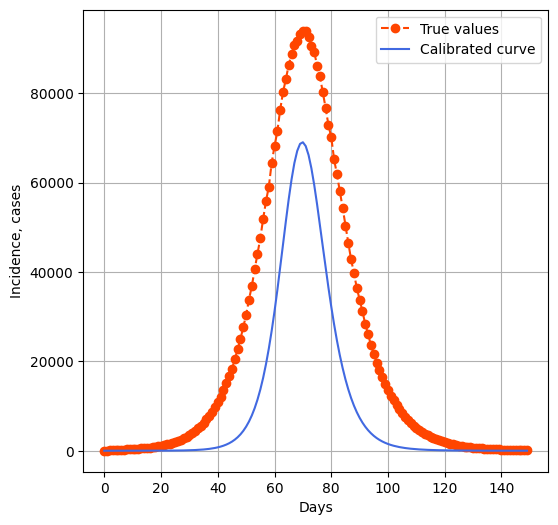

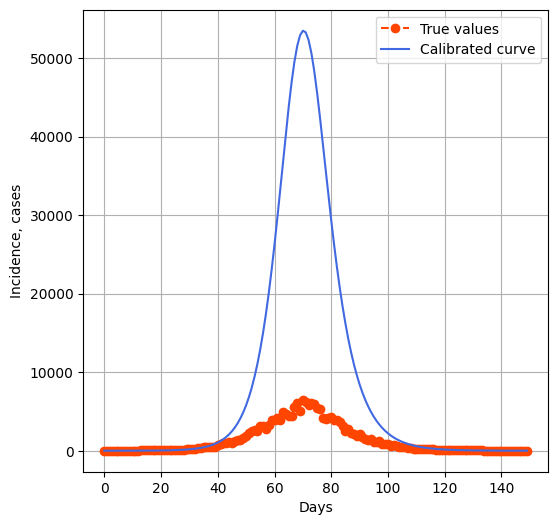

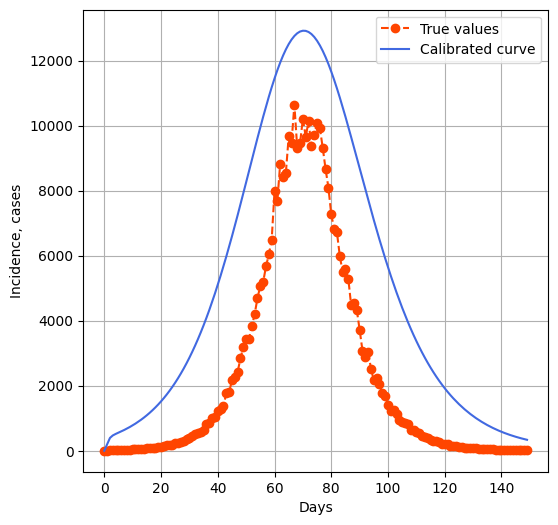

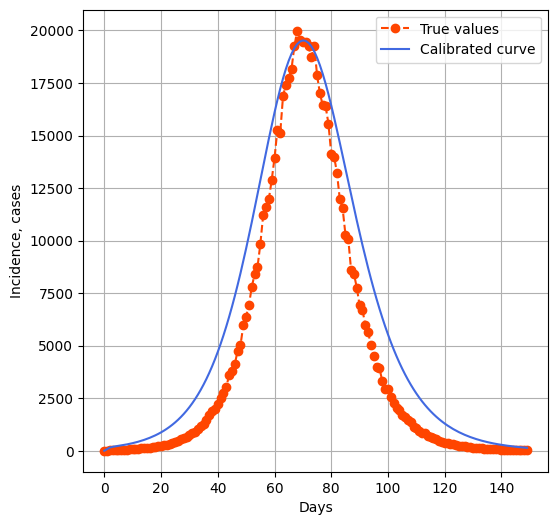

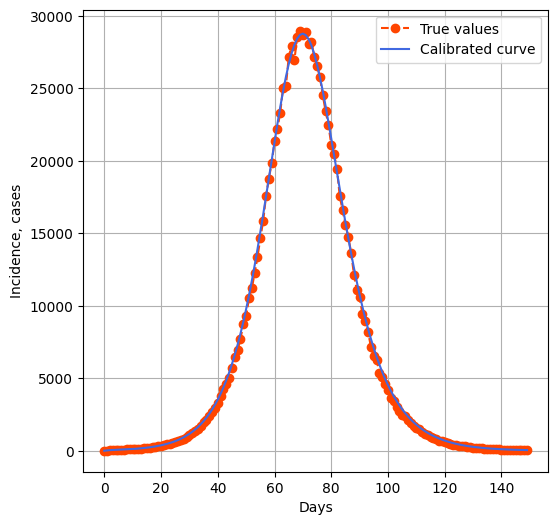

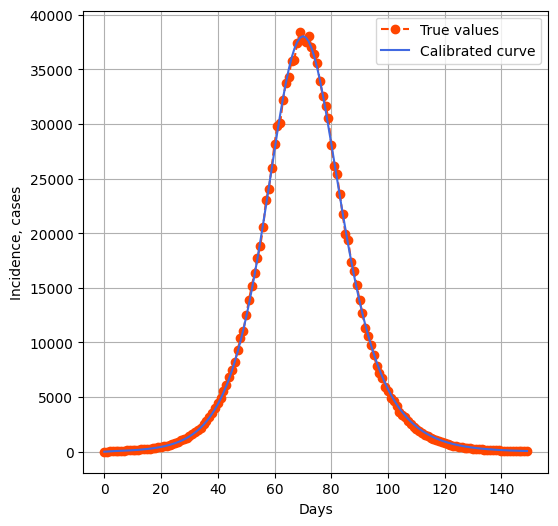

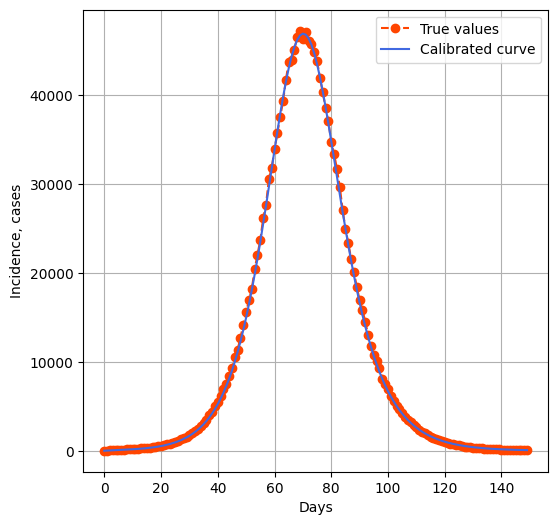

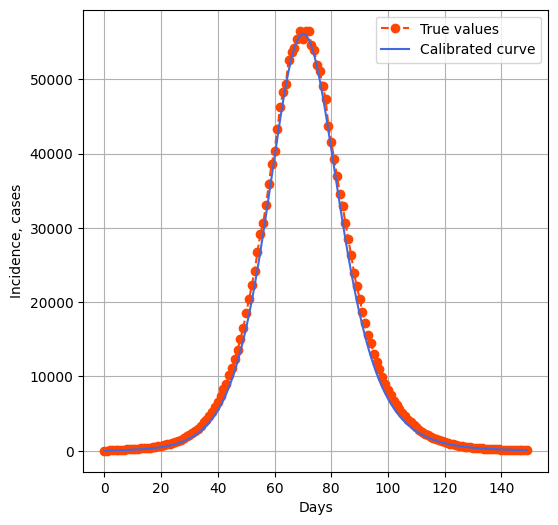

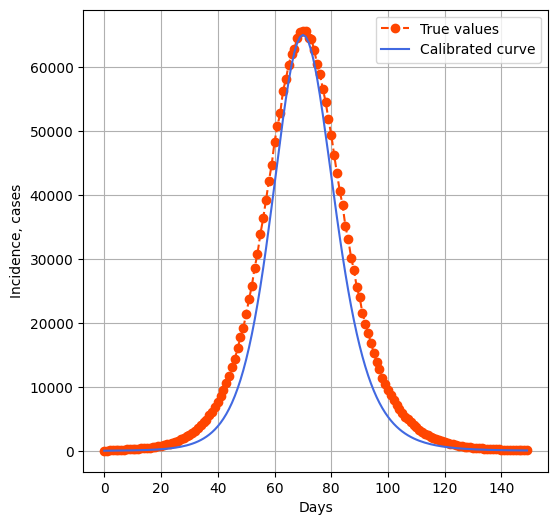

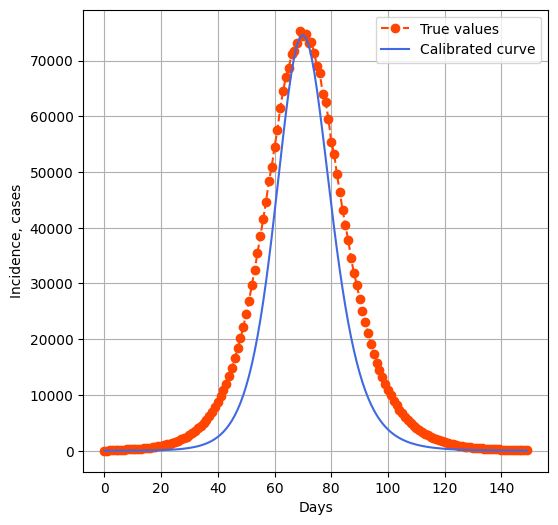

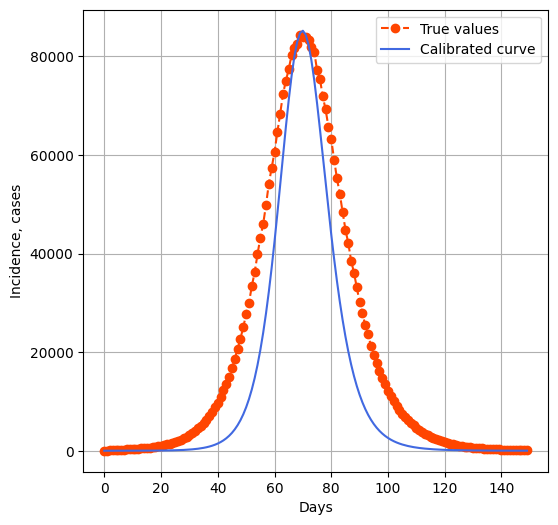

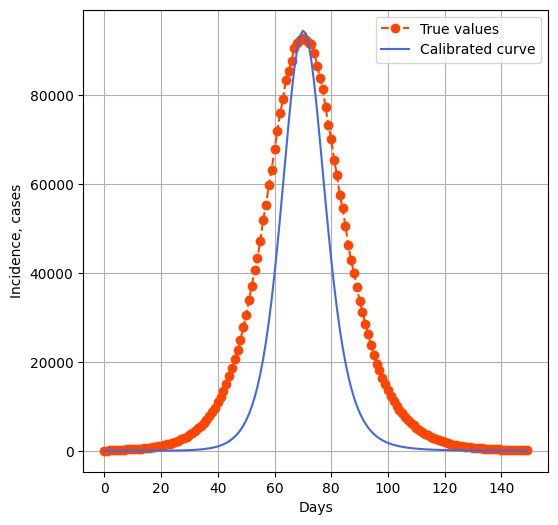

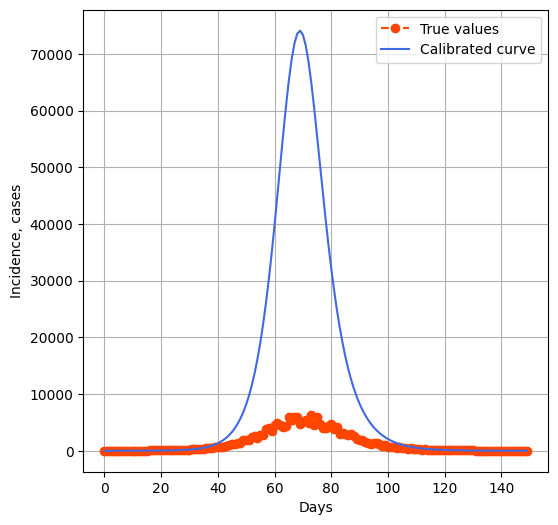

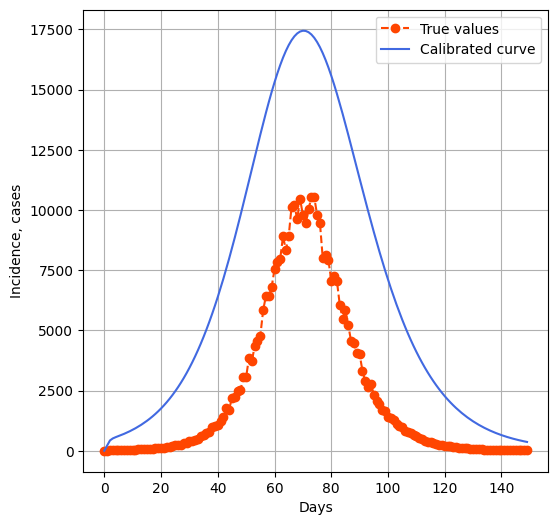

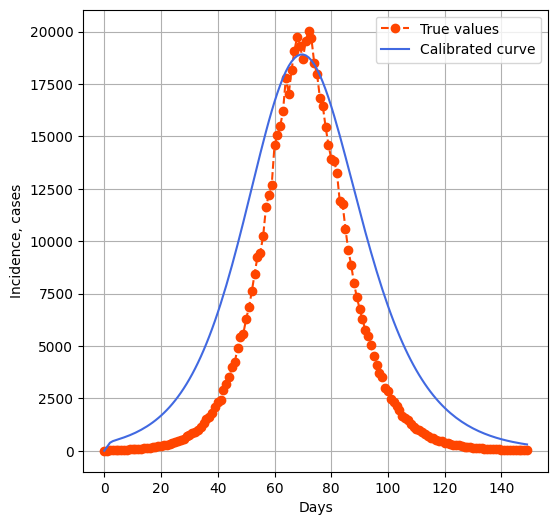

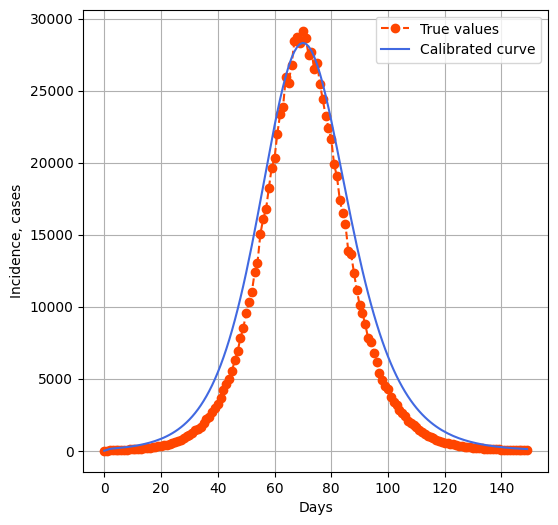

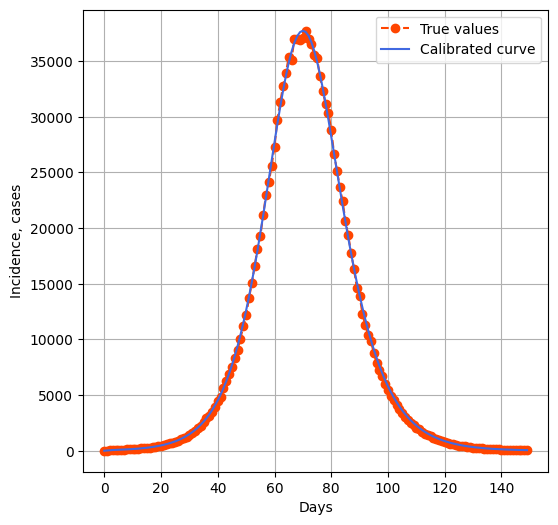

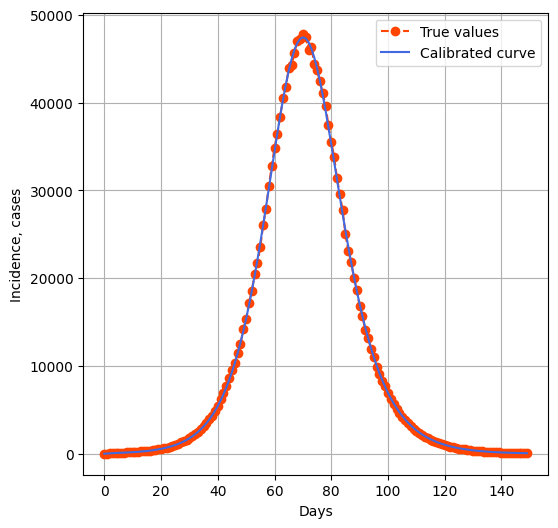

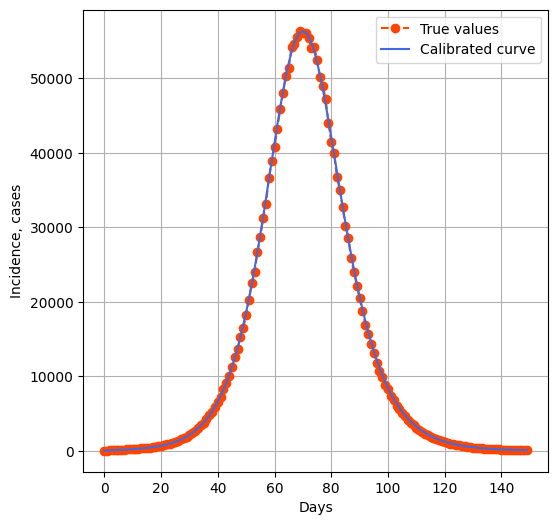

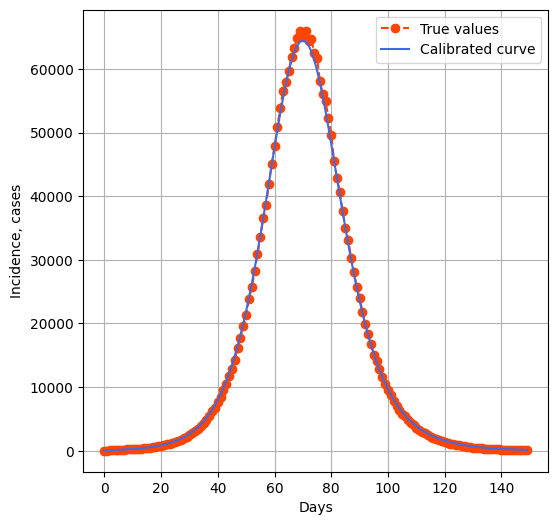

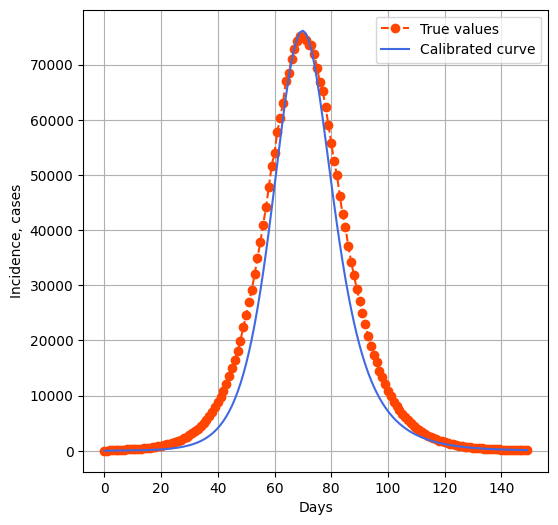

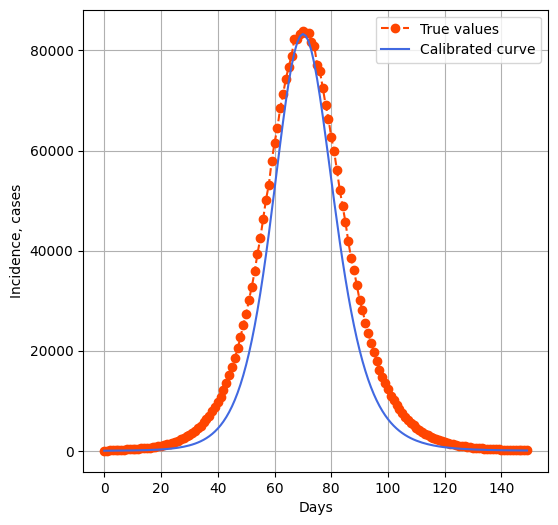

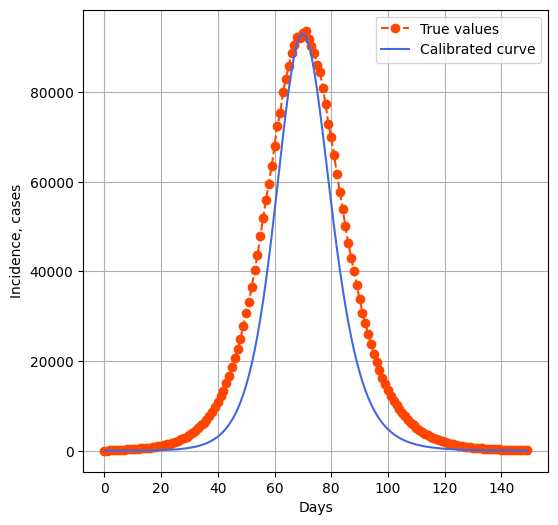

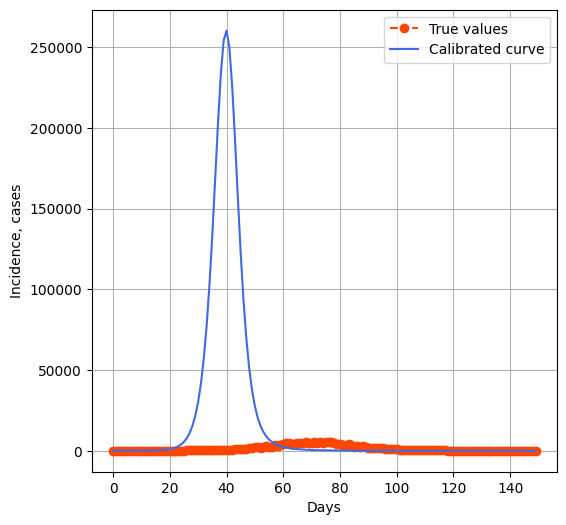

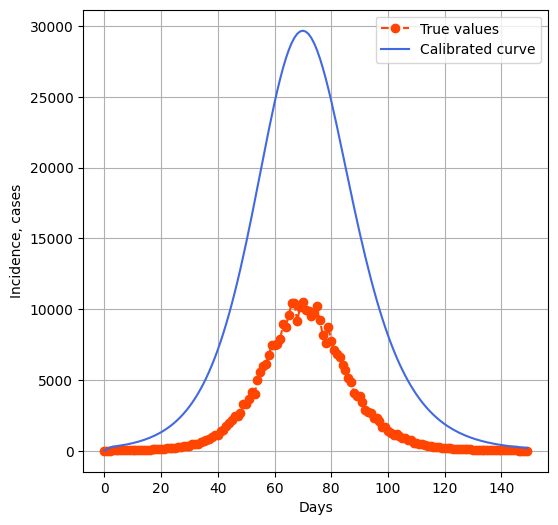

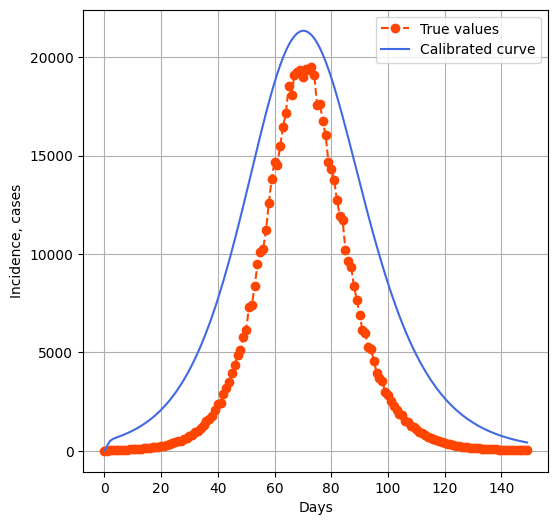

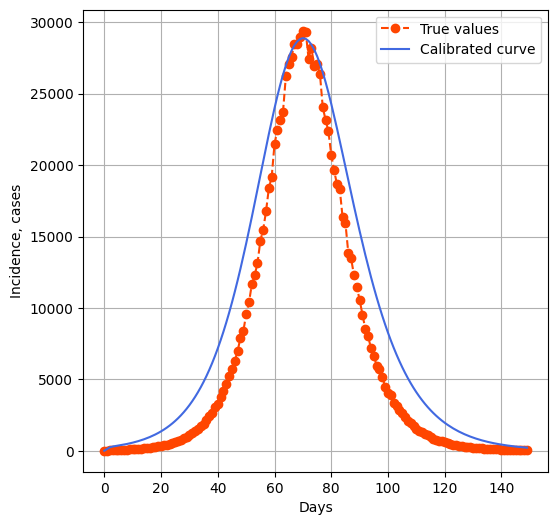

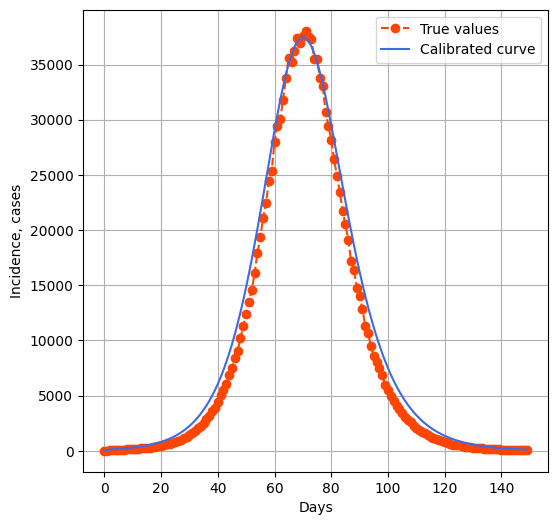

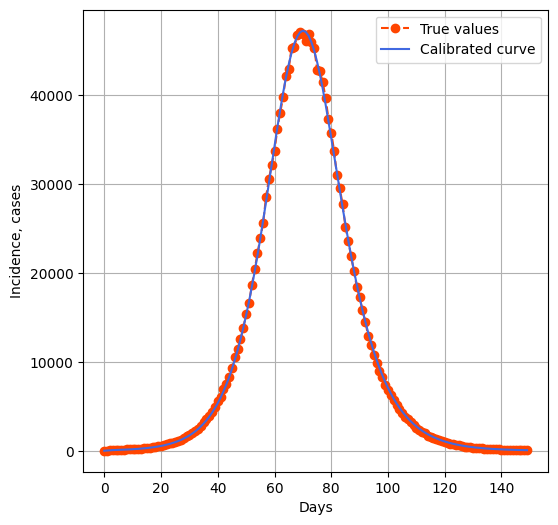

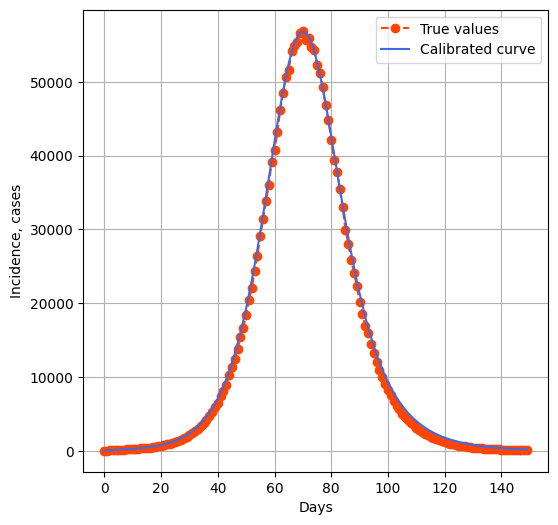

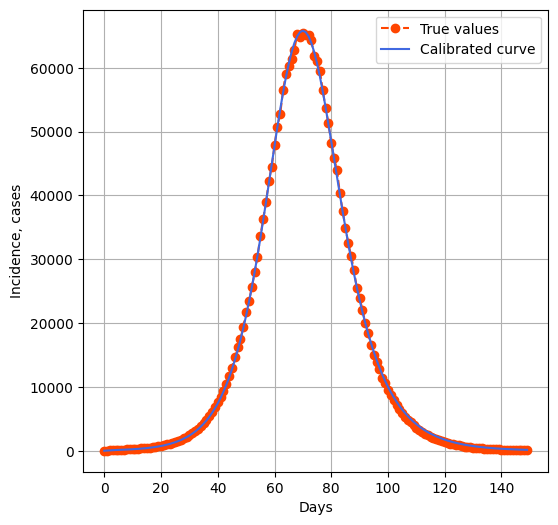

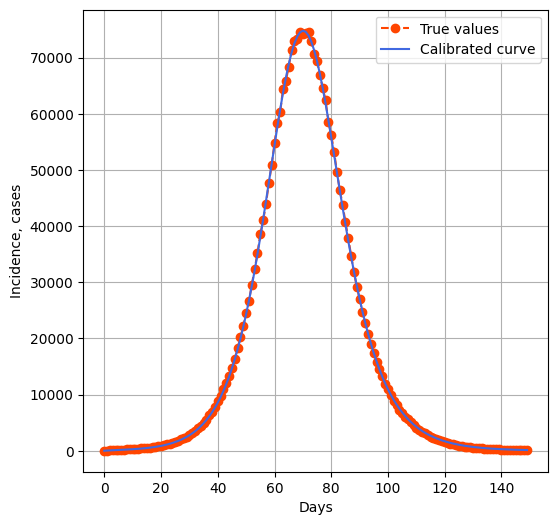

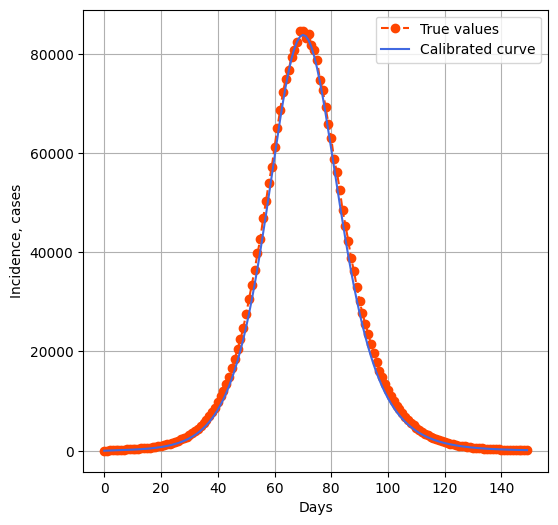

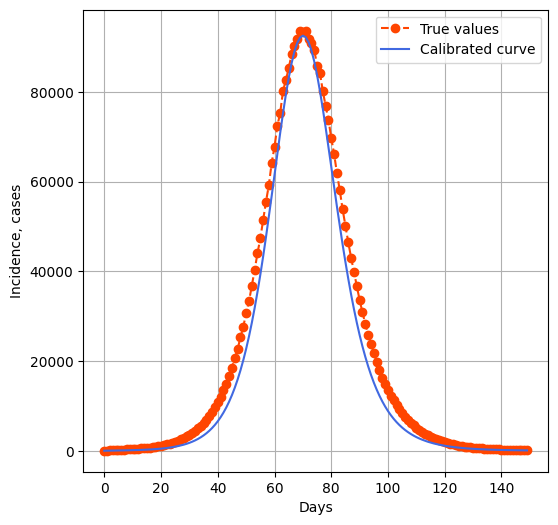

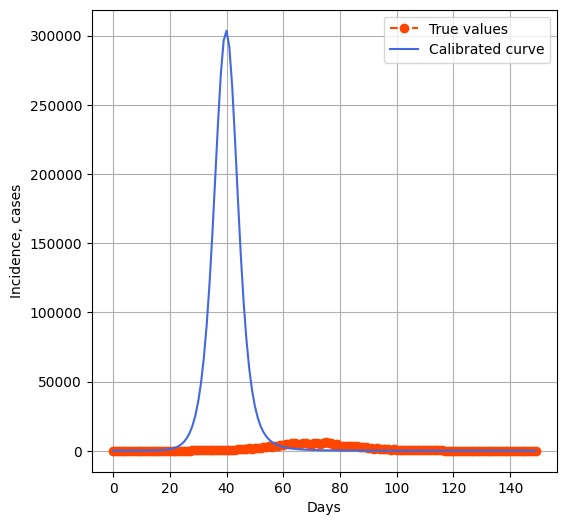

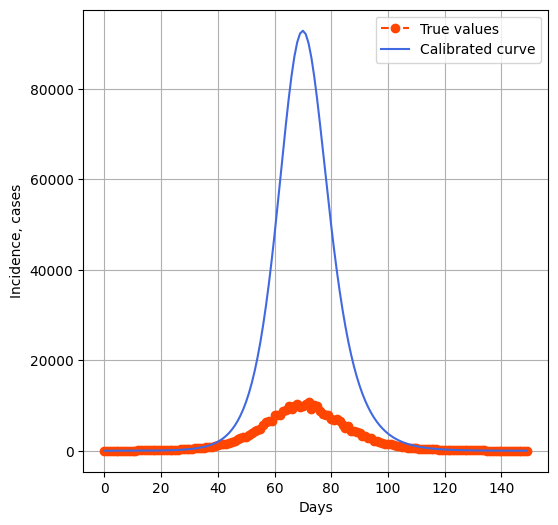

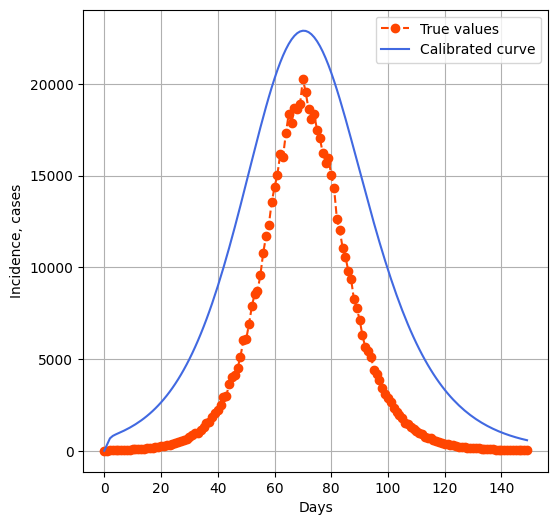

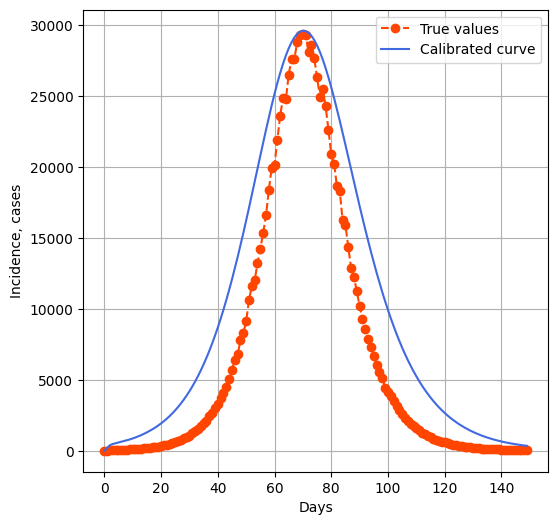

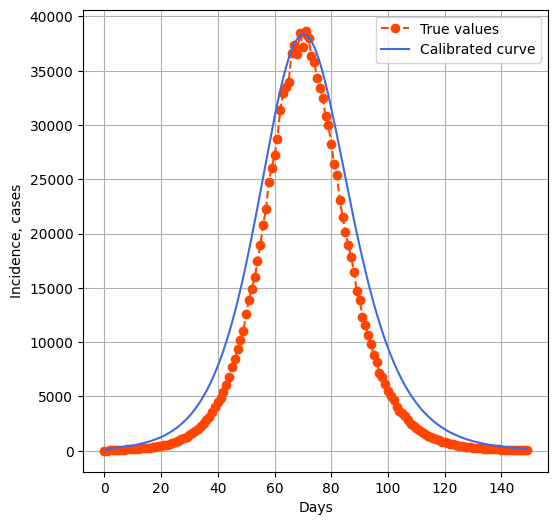

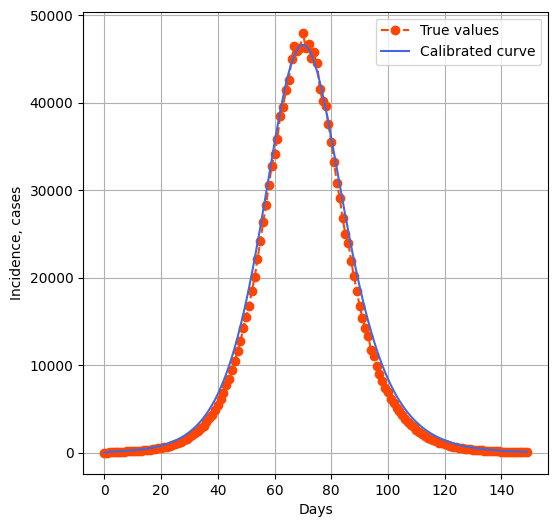

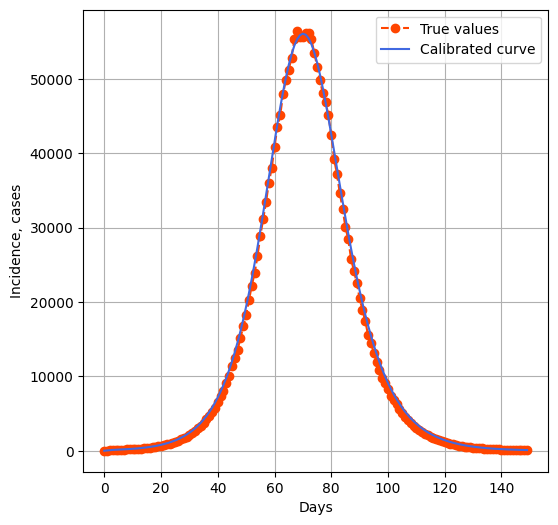

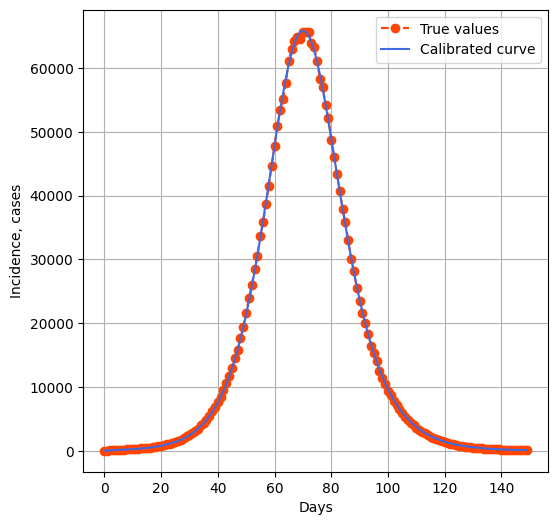

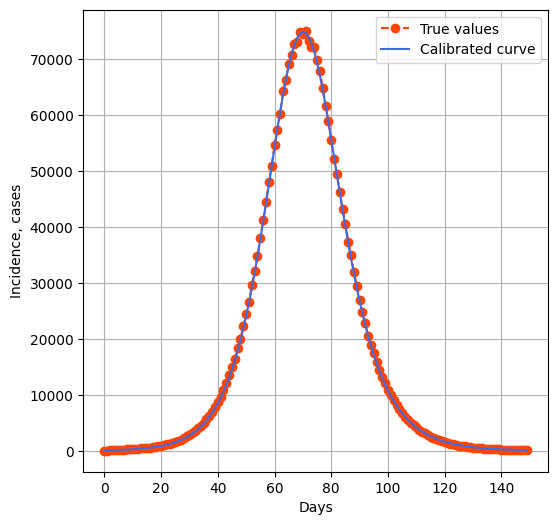

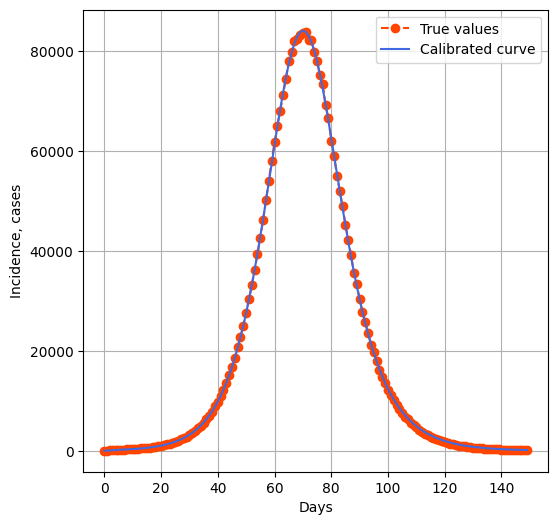

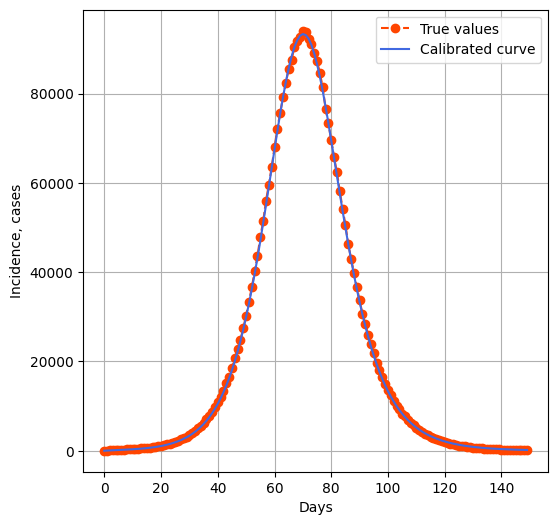

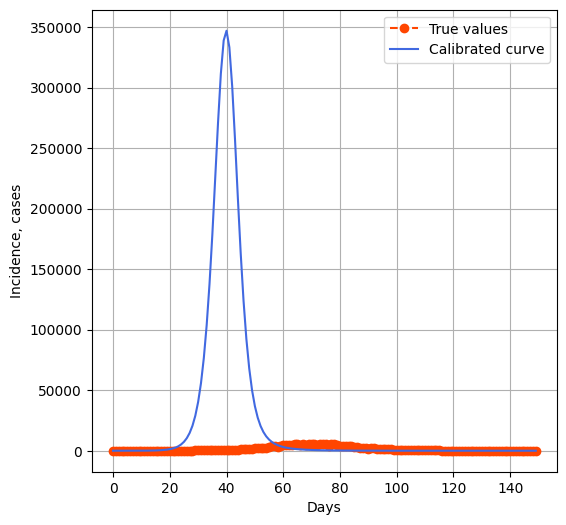

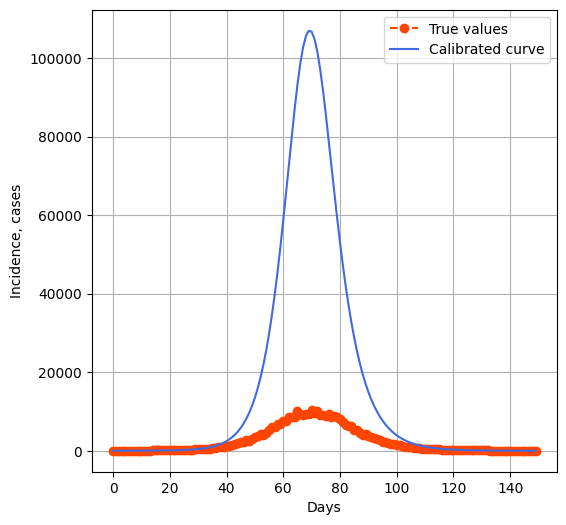

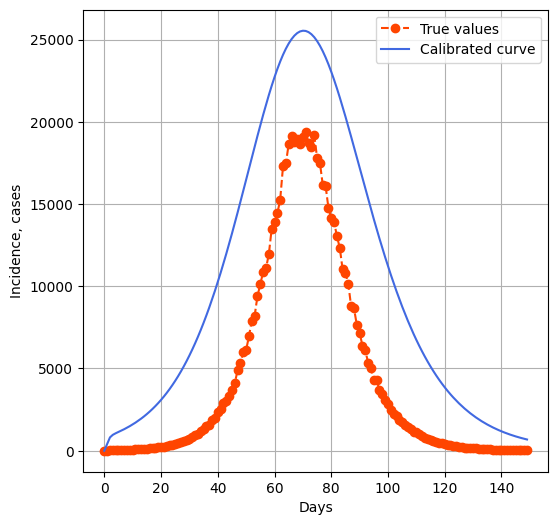

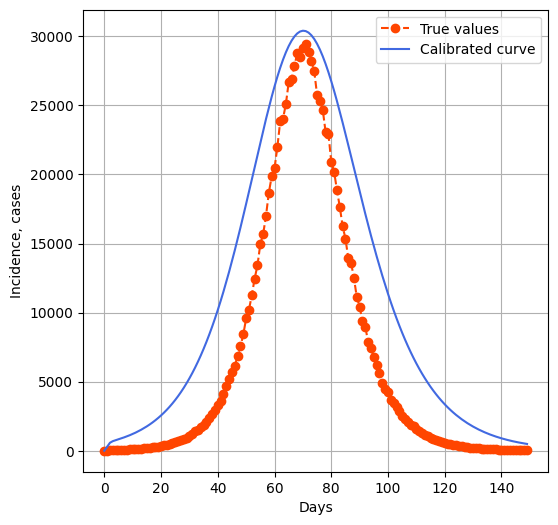

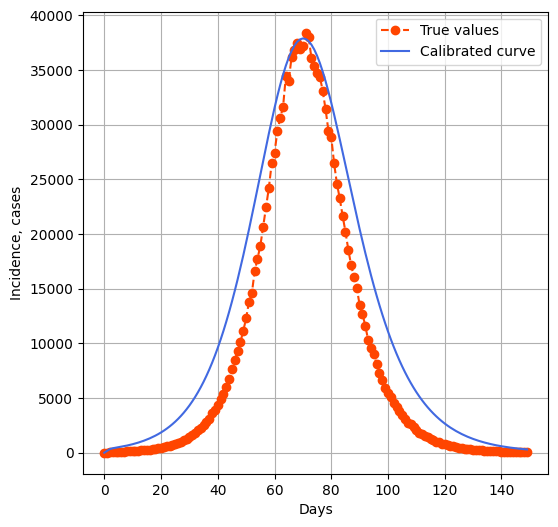

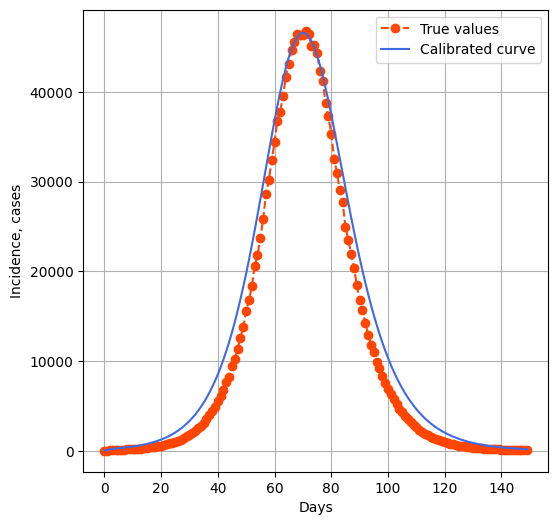

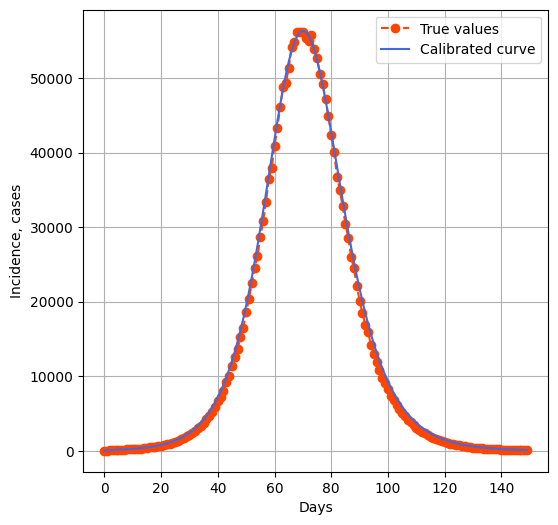

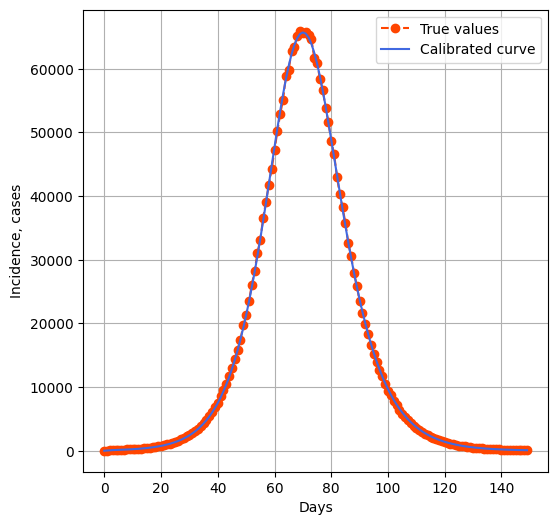

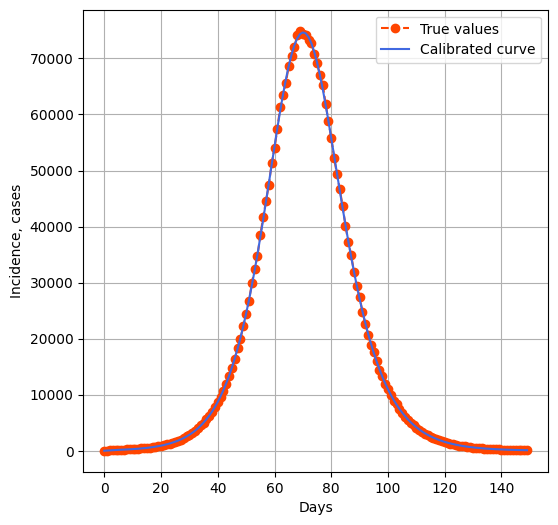

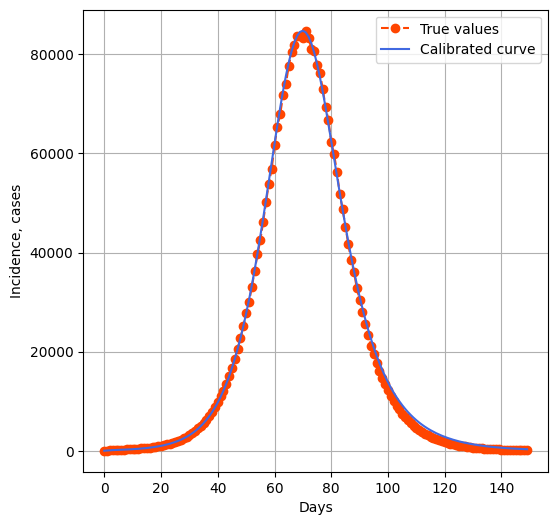

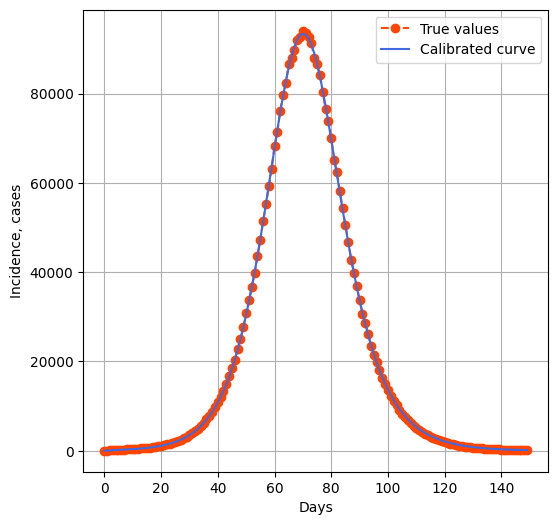

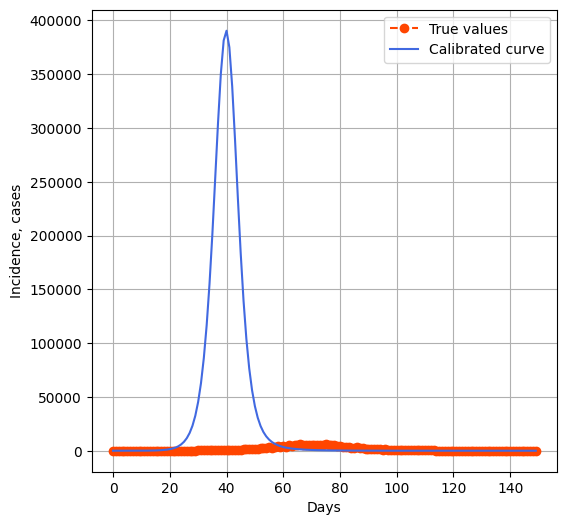

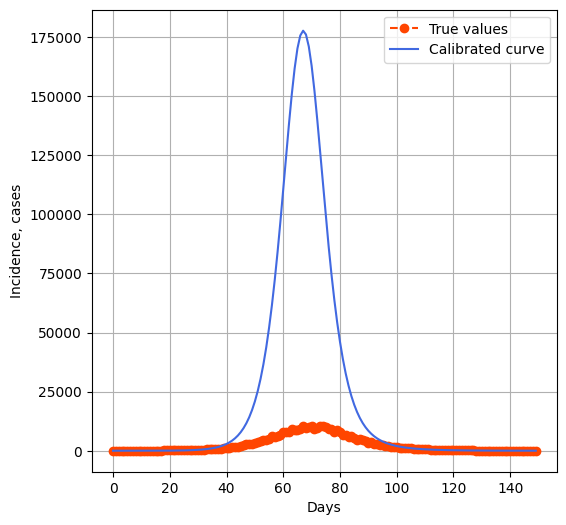

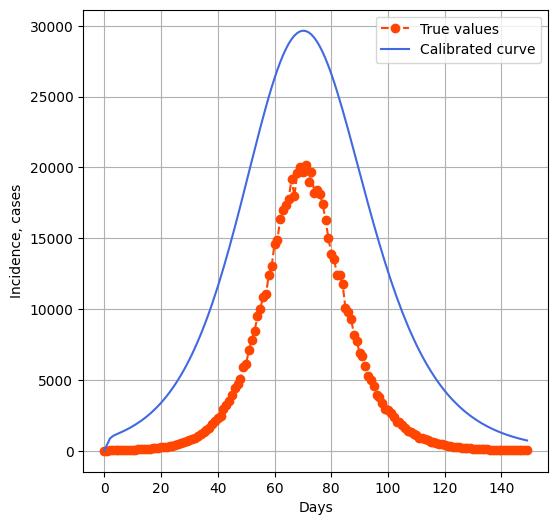

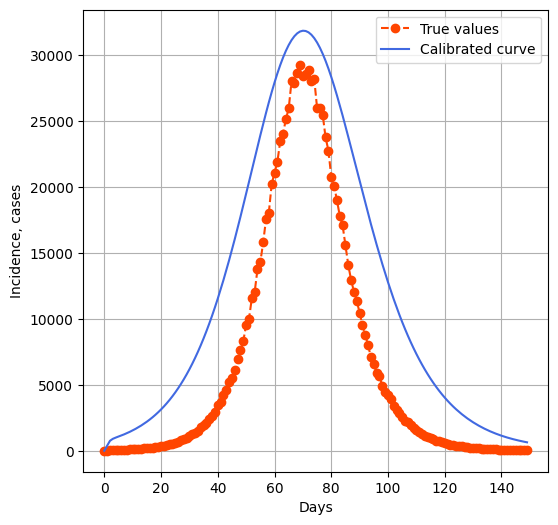

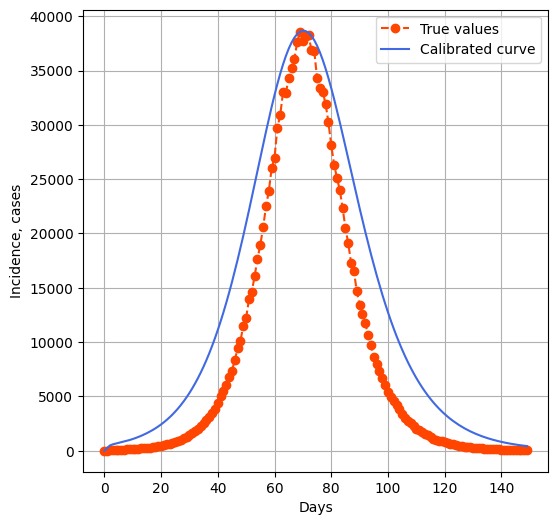

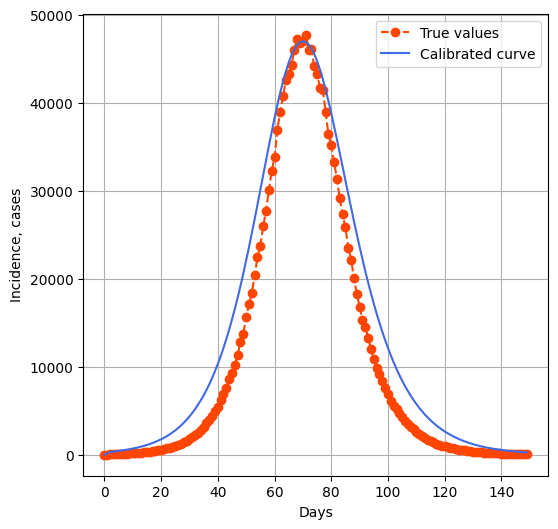

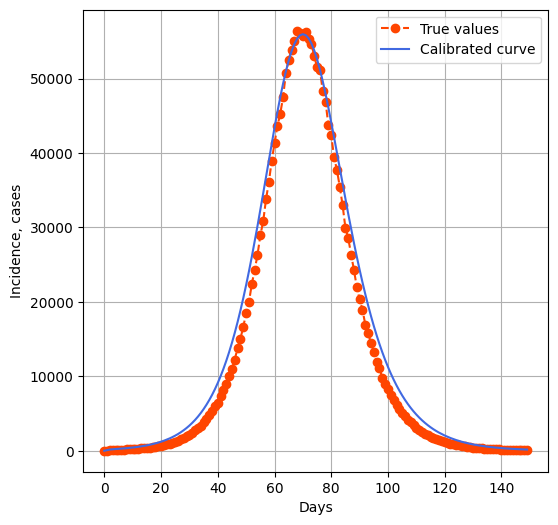

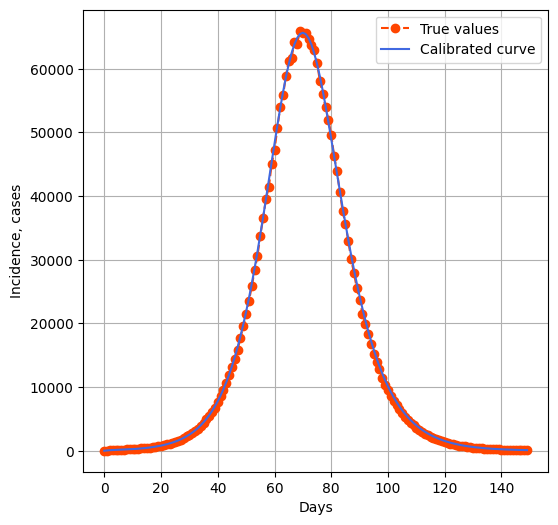

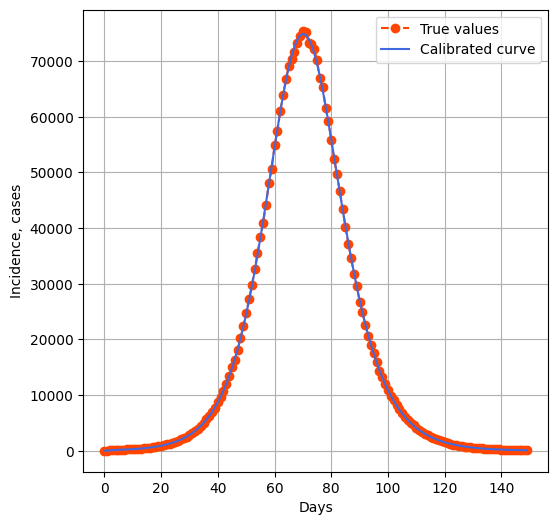

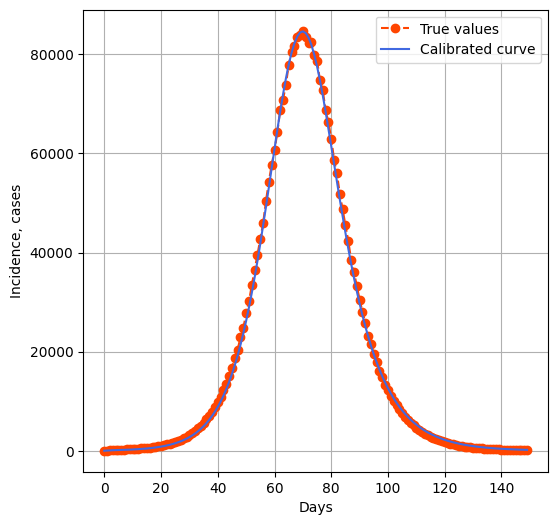

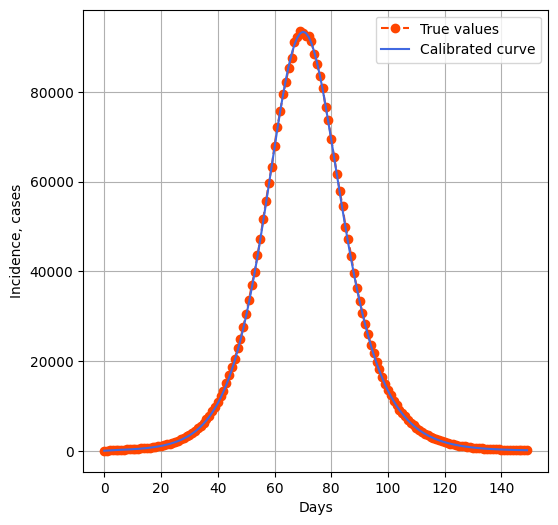

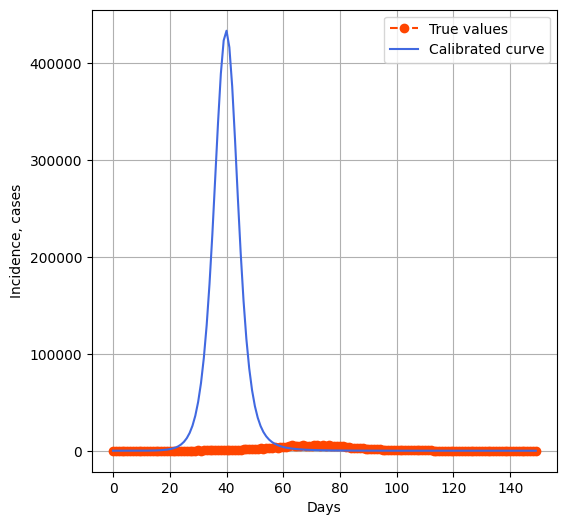

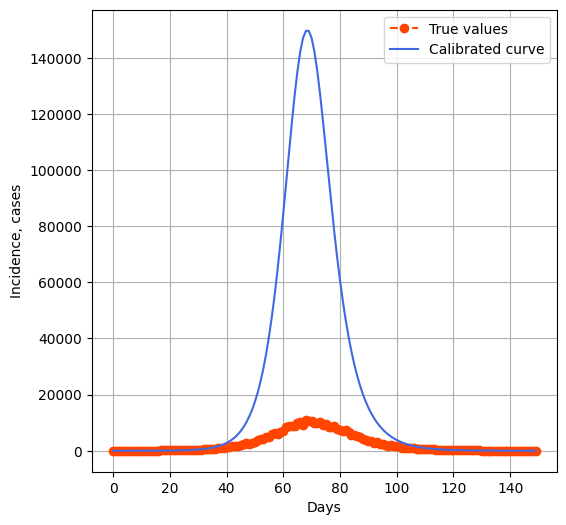

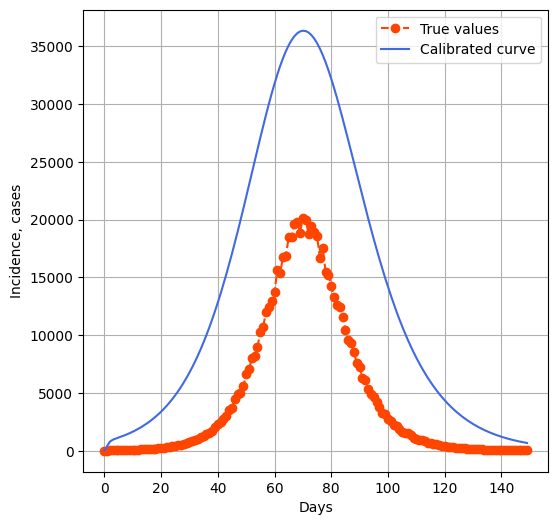

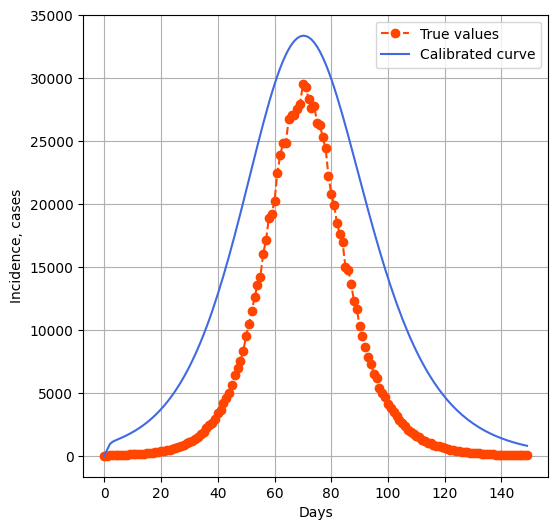

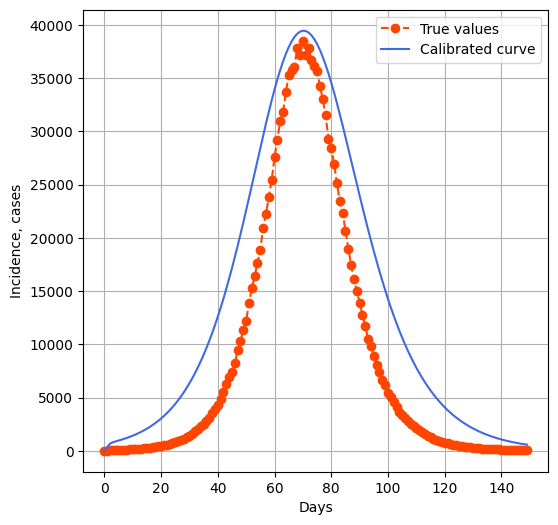

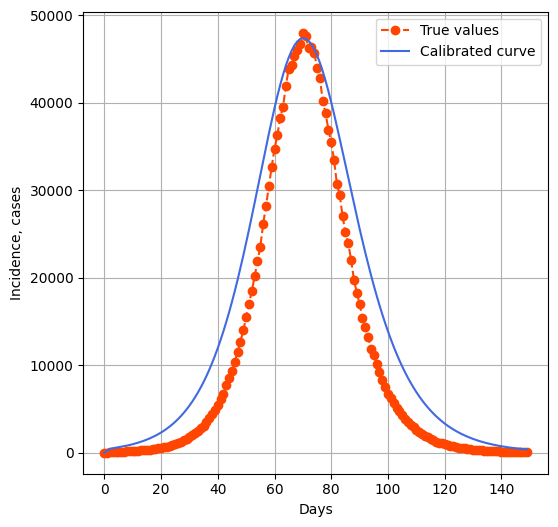

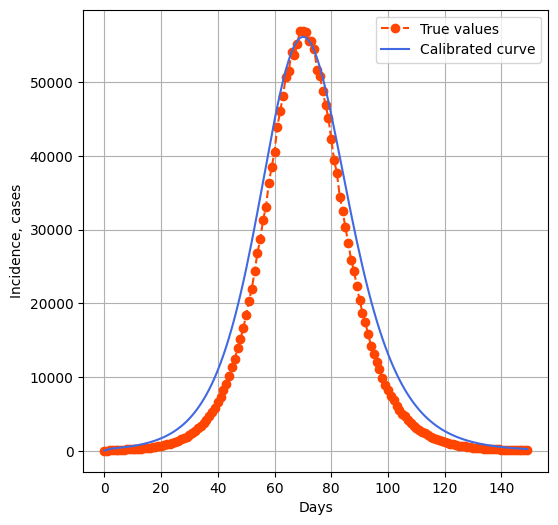

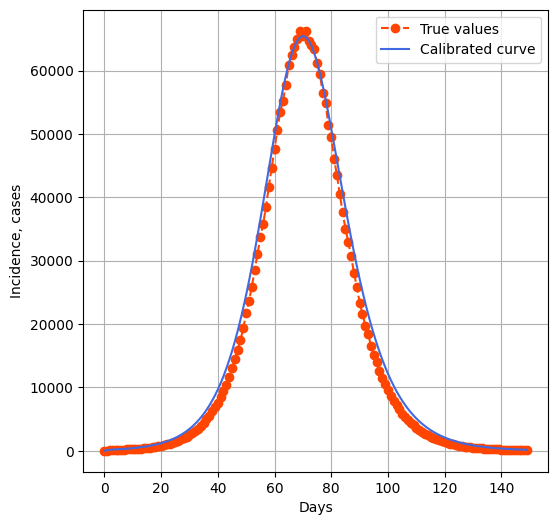

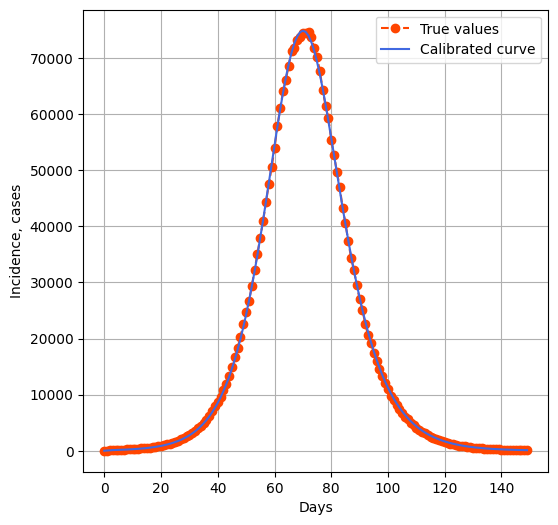

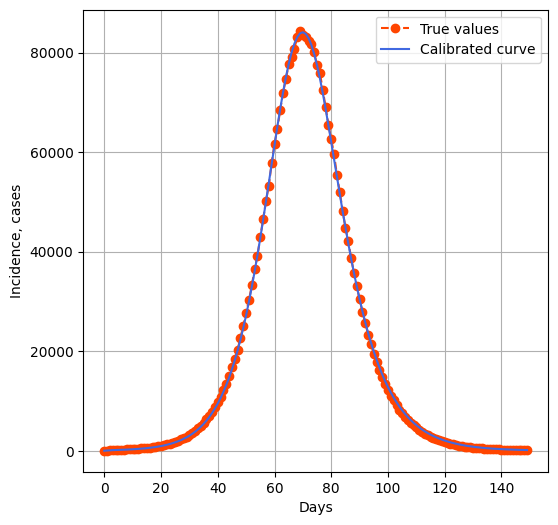

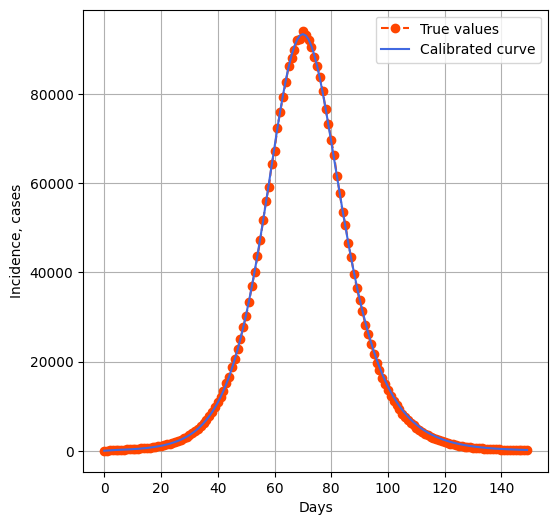

In [3]:
population = 5*1e6
mean_underreporting_arr = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
r2_arr = []
for population_scaling in tqdm.tqdm(mean_underreporting_arr):
    r2_cur_arr = []
    for mean_underreporting in mean_underreporting_arr:
        model = SEIRModel(population=population*population_scaling)
        error_model = NaiveErrorModel(data_full.daily_incidence, mean_delay=0, 
                                        mean_underreporting=mean_underreporting, error_mode='random')
        error_model.add_underreporting()
        data = error_model.incidence_arr
        estimated_params, r2_estimated = model.calibrate(data)
        r2_cur_arr.append(r2_estimated)
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlabel('Days')
        ax.set_ylabel('Incidence, cases')
        ax.plot(data, '--o', color='OrangeRed', label='True values')
        sim = model.simulate(*estimated_params.as_list(), tmax=150)
        ax.plot(sim.daily_incidence, color='RoyalBlue', label='Calibrated curve')
        ax.grid()
        ax.legend()
        fig.savefig('../figures/calibration_population_scale_{}_underreporting_random_mode_{}.png'.format(population_scaling, mean_underreporting))
    r2_arr.append(r2_cur_arr)

In [5]:
np.savetxt('../data/r2_arr_underreporting_random.npy', r2_arr)

In [ ]:
a = np.loadtxt('../data/r2_arr_underreprting.npy')

In [ ]:
r2_arr = a

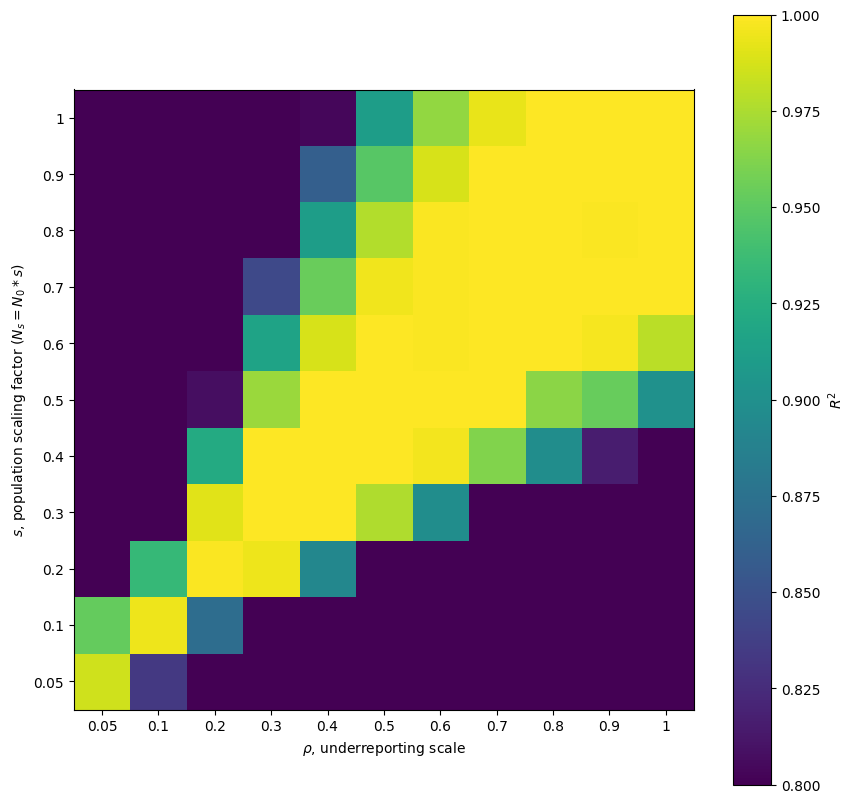

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xticks(ticks=np.arange(len(mean_underreporting_arr)), labels=[round(elem, 2) for elem in mean_underreporting_arr])
ax.set_yticks(ticks=np.arange(len(mean_underreporting_arr)), labels=[round(elem, 2) for elem in mean_underreporting_arr])

r2_numpy_arr = np.array(r2_arr)
norm = mpl.colors.Normalize(vmin=0.8, vmax=1)

im = ax.imshow(r2_numpy_arr, cmap='viridis', interpolation='nearest', norm=norm, origin='lower')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('$R^2$')
# ax.set_title('Colormap 2D Plot of R2 Scores')
ax.set_xlabel(r'$\rho$, underreporting scale')
ax.set_ylabel(r'$s$, population scaling factor ($N_s = N_0*s$)')
fig.savefig('../figures/colormap_r2_underreporting_random.pdf', bbox_inches='tight')
fig.savefig('../figures/colormap_r2_underreporting_random.png', bbox_inches='tight', dpi=600)

In [ ]:
population = 5*1e6
mean_delay_arr = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
r2_arr = []
for add_delay in tqdm.tqdm(mean_delay_arr):
    r2_cur_arr = []
    for subtract_delay in mean_delay_arr:
        model = SEIRModel(population=population)
        error_model = NaiveErrorModel(data_full.daily_incidence, mean_delay=add_delay, 
                                        mean_underreporting=1, error_mode='fixed')
        error_model.add_noise()
        error_model.subtract_delay(mean_delay=subtract_delay)
        data = error_model.incidence_arr
        estimated_params, r2_estimated = model.calibrate(data)
        r2_cur_arr.append(r2_estimated)
        fig, ax = plt.subplots(figsize=(6,6))
        ax.set_xlabel('Days')
        ax.set_ylabel('Incidence, cases')
        ax.plot(data, '--o', color='OrangeRed', label='True values')
        sim = model.simulate(*estimated_params.as_list(), tmax=150)
        ax.plot(sim.daily_incidence, color='RoyalBlue', label='Calibrated curve')
        ax.grid()
        ax.legend()
        fig.savefig('../figures/calibration_add_delay_{}_subtract_delay_{}.png'.format(add_delay, subtract_delay))
    r2_arr.append(r2_cur_arr)

In [ ]:
np.savetxt('../data/r2_arr_delay.npy', r2_arr)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xticks(ticks=np.arange(len(mean_delay_arr)), labels=mean_delay_arr)
ax.set_yticks(ticks=np.arange(len(mean_delay_arr)), labels=mean_delay_arr)

r2_numpy_arr = np.array(r2_arr)
norm = mpl.colors.Normalize(vmin=0.99, vmax=1)

im = ax.imshow(r2_numpy_arr, cmap='viridis', interpolation='nearest', norm=norm, origin='lower')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('$R^2$', fontsize=16)
# ax.set_title('Colormap 2D Plot of R2 Scores')
ax.set_xlabel(r'Delay subtracted, days')
ax.set_ylabel(r'Delay added, days')
fig.savefig('../figures/colormap_r2_fixed_delay.pdf', bbox_inches='tight')
fig.savefig('../figures/colormap_r2_fixed_delay.png', bbox_inches='tight', dpi=600)